## COL funtional visualization 012025 & 032024 reads

samples have been run through humann3 and identified genefamilies merged into 1 tsv (see  COL_functional_analysis_012025_032024.ipnyb)

In [1]:
#load libraries (not sure I need all these, but just in case)
library(tidyverse)
library(vegan)
library(phyloseq)
library(ggplot2)
library(RColorBrewer)
library(DESeq2)
library(dplyr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following obj

In [2]:
getwd()

[1] "/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL"

In [2]:
setwd("/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/humann3_functional_analysis_032024_012025/")

In [3]:
genes = read.csv("all_genefamilies_filtered_rxn_cpm_named.csv")

In [4]:
head(genes)

,X..Gene.Family,X012025_COL_SAN_T5_568_OFAV_S1_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_569_DLAB_S2_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_570_DLAB_S3_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_571_DLAB_S4_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_572_OFAV_S5_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_573_PSTR_S6_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_574_MCAV_S7_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_575_DLAB_S8_comb_kraken_filtered_Abundance.CPM,X012025_COL_SAN_T5_576_PSTR_S9_comb_kraken_filtered_Abundance.CPM,⋯,X032024_COL_SAN_T5_150_MCAV_S8_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_154_PSTR_S38_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_158_DLAB_S15_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_159_DLAB_S16_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_160_DLAB_S41_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_161_DLAB_S42_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_162_PSTR_S39_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_163_PSTR_S11c_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_166_OFAV_S20_comb_kraken_filtered_Abundance.CPM,X032024_COL_SAN_T5_167_OFAV_S21_comb_kraken_filtered_Abundance.CPM
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,UNGROUPED,988274,872601,811874.0000,844409.0000,993706,827667.0000,981995,787004.0000,987204,⋯,771819.0000,977589,969526,986003,913695.0000,7.60019e+05,869973,976919,970821,9.94356e+05
2,UNGROUPED|g__Bradyrhizobium.s__Bradyrhizobium_sp_MOS004,0,0,0.0000,0.0000,0,0.0000,0,0.0000,0,⋯,0.0000,0,0,0,0.0000,0.00000e+00,171999,0,0,0.00000e+00
3,UNGROUPED|g__Cutibacterium.s__Cutibacterium_acnes,0,0,0.0000,103703.0000,0,0.0000,0,0.0000,0,⋯,0.0000,0,0,0,0.0000,0.00000e+00,0,0,0,0.00000e+00
4,UNGROUPED|g__Moraxella.s__Moraxella_osloensis,0,0,0.0000,0.0000,0,0.0000,0,0.0000,0,⋯,0.0000,0,0,0,0.0000,0.00000e+00,0,0,0,0.00000e+00
5,UNGROUPED|unclassified,988274,872601,811874.0000,740707.0000,993706,827667.0000,981995,787004.0000,987204,⋯,771819.0000,977589,969526,986003,913695.0000,7.60019e+05,697974,976919,970821,9.94356e+05
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,0,37.2786,25.7496,0,18.9406,0,22.1238,0,⋯,55.0468,0,0,0,23.6842,5.60423e+00,0,0,0,9.45823e+00


In [5]:
#change headers
names(genes)[1] <- "Gene_Family"
names(genes) <- sub("^X", "", names(genes))
names(genes) <- sub("_comb_kraken_filtered_Abundance.CPM","", names(genes))
head(genes)

,Gene_Family,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,UNGROUPED,988274,872601,811874.0000,844409.0000,993706,827667.0000,981995,787004.0000,987204,⋯,771819.0000,977589,969526,986003,913695.0000,7.60019e+05,869973,976919,970821,9.94356e+05
2,UNGROUPED|g__Bradyrhizobium.s__Bradyrhizobium_sp_MOS004,0,0,0.0000,0.0000,0,0.0000,0,0.0000,0,⋯,0.0000,0,0,0,0.0000,0.00000e+00,171999,0,0,0.00000e+00
3,UNGROUPED|g__Cutibacterium.s__Cutibacterium_acnes,0,0,0.0000,103703.0000,0,0.0000,0,0.0000,0,⋯,0.0000,0,0,0,0.0000,0.00000e+00,0,0,0,0.00000e+00
4,UNGROUPED|g__Moraxella.s__Moraxella_osloensis,0,0,0.0000,0.0000,0,0.0000,0,0.0000,0,⋯,0.0000,0,0,0,0.0000,0.00000e+00,0,0,0,0.00000e+00
5,UNGROUPED|unclassified,988274,872601,811874.0000,740707.0000,993706,827667.0000,981995,787004.0000,987204,⋯,771819.0000,977589,969526,986003,913695.0000,7.60019e+05,697974,976919,970821,9.94356e+05
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,0,37.2786,25.7496,0,18.9406,0,22.1238,0,⋯,55.0468,0,0,0,23.6842,5.60423e+00,0,0,0,9.45823e+00


In [6]:
#remove specific rows
genes_filtered <- genes[!grepl("UNMAPPED|UNGROUPED", genes$Gene_Family), ]
#genes <- genes[!grepl("UNGROUPED", genes$Gene_Family), ]
head(genes_filtered)

,Gene_Family,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,0.0000,37.2786,25.7496,0.00000,18.94060,0,22.1238,0,⋯,55.04680,0,0,0,23.6842,5.60423,0.0000,0,0,9.45823
7,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51]|unclassified,0,0.0000,37.2786,25.7496,0.00000,18.94060,0,22.1238,0,⋯,55.04680,0,0,0,23.6842,5.60423,0.0000,0,0,9.45823
8,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,49.3798,0.0000,0.0000,5.41724,16.10200,0,29.9394,0,⋯,2.82153,0,0,0,0.0000,11.17880,22.6396,0,0,0.00000
9,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127]|unclassified,0,49.3798,0.0000,0.0000,5.41724,16.10200,0,29.9394,0,⋯,2.82153,0,0,0,0.0000,11.17880,22.6396,0,0,0.00000
10,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0.0000,0.0000,0.0000,0.00000,3.96876,0,0.0000,0,⋯,8.27379,0,0,0,0.0000,0.00000,0.0000,0,0,0.00000
11,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136]|unclassified,0,0.0000,0.0000,0.0000,0.00000,3.96876,0,0.0000,0,⋯,8.27379,0,0,0,0.0000,0.00000,0.0000,0,0,0.00000


In [7]:
#remove the "unclassified" versions 
genes_filtered <- genes_filtered[!grepl("unclassified", genes_filtered$Gene_Family), ]
head(genes_filtered)
dim(genes_filtered)

,Gene_Family,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,0.0000,37.2786,25.7496,0.00000,18.94060,0,22.1238,0,⋯,55.04680,0,0,0,23.6842,5.60423,0.0000,0,0,9.45823
8,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,49.3798,0.0000,0.0000,5.41724,16.10200,0,29.9394,0,⋯,2.82153,0,0,0,0.0000,11.17880,22.6396,0,0,0.00000
10,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0.0000,0.0000,0.0000,0.00000,3.96876,0,0.0000,0,⋯,8.27379,0,0,0,0.0000,0.00000,0.0000,0,0,0.00000
12,1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],0,0.0000,0.0000,0.0000,5.85221,0.00000,0,0.0000,0,⋯,0.00000,0,0,0,0.0000,0.00000,0.0000,0,0,0.00000
14,1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],0,0.0000,0.0000,0.0000,0.00000,0.00000,0,0.0000,0,⋯,0.00000,0,0,0,0.0000,32.47770,0.0000,0,0,0.00000
16,1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0,0.0000,0.0000,0.0000,0.00000,0.00000,0,0.0000,0,⋯,0.00000,0,0,0,0.0000,64.32320,0.0000,0,0,0.00000


[1] 6429   57

In [8]:
#remove rows with "g__Cutibacterium.s__Cutibacterium_acnes" and "g__Bradyrhizobium.s__Bradyrhizobium_sp_MOS004"
genes_filtered <- genes_filtered[!grepl("g__Bradyrhizobium.s__Bradyrhizobium_sp_MOS004|g__Cutibacterium.s__Cutibacterium_acnes|g__Moraxella.s__Moraxella_osloensis", genes_filtered$Gene_Family), ]
head(genes_filtered)
dim (genes_filtered)

,Gene_Family,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,0.0000,37.2786,25.7496,0.00000,18.94060,0,22.1238,0,⋯,55.04680,0,0,0,23.6842,5.60423,0.0000,0,0,9.45823
8,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,49.3798,0.0000,0.0000,5.41724,16.10200,0,29.9394,0,⋯,2.82153,0,0,0,0.0000,11.17880,22.6396,0,0,0.00000
10,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0.0000,0.0000,0.0000,0.00000,3.96876,0,0.0000,0,⋯,8.27379,0,0,0,0.0000,0.00000,0.0000,0,0,0.00000
12,1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],0,0.0000,0.0000,0.0000,5.85221,0.00000,0,0.0000,0,⋯,0.00000,0,0,0,0.0000,0.00000,0.0000,0,0,0.00000
14,1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],0,0.0000,0.0000,0.0000,0.00000,0.00000,0,0.0000,0,⋯,0.00000,0,0,0,0.0000,32.47770,0.0000,0,0,0.00000
16,1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0,0.0000,0.0000,0.0000,0.00000,0.00000,0,0.0000,0,⋯,0.00000,0,0,0,0.0000,64.32320,0.0000,0,0,0.00000


[1] 3405   57

In [9]:
#just checking to see
write.csv(as.data.frame(genes_filtered), file= "all_genes_filtered.csv")

In [34]:
#reorder columns from list file (just concatenated the IDs together in the order I wanted
#also included Gene_Family first, to keep that the first column
column_list <- readLines("COL_column_order.txt")
genes_filtered_reordered <- genes_filtered[, column_list]
head(genes_filtered_reordered)

,Gene_Family,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,⋯,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,012025_COL_SAN_T5_587_PSTR_S20,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,0,0,0,9.45823,0,0.00000,0,0,⋯,0,0,0.0000,18.94060,0,0.00000,0,12.0018,0.0000,0
8,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,0,0,0,0.00000,0,5.41724,0,0,⋯,0,0,22.6396,16.10200,0,7.75194,0,0.0000,50.2233,0
10,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0,0,0,0.00000,0,0.00000,0,0,⋯,0,0,0.0000,3.96876,0,0.00000,0,0.0000,0.0000,0
12,1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],0,0,0,0,0.00000,0,5.85221,0,0,⋯,0,0,0.0000,0.00000,0,0.00000,0,0.0000,0.0000,0
14,1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],0,0,0,0,0.00000,0,0.00000,0,0,⋯,0,0,0.0000,0.00000,0,0.00000,0,0.0000,13.8331,0
16,1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0,0,0,0,0.00000,0,0.00000,0,0,⋯,0,0,0.0000,0.00000,0,0.00000,0,0.0000,11.6232,0


In [11]:
# make the index the gene_family
row.names(genes_filtered_reordered) <- genes_filtered_reordered$Gene_Family
genes_filtered_reordered$Gene_Family <- NULL
head(genes_filtered_reordered)

,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,⋯,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,012025_COL_SAN_T5_587_PSTR_S20,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,0,0,0,9.45823,0,0.00000,0,0,0,⋯,0,0,0.0000,18.94060,0,0.00000,0,12.0018,0.0000,0
1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,0,0,0,0.00000,0,5.41724,0,0,0,⋯,0,0,22.6396,16.10200,0,7.75194,0,0.0000,50.2233,0
1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0,0,0,0.00000,0,0.00000,0,0,0,⋯,0,0,0.0000,3.96876,0,0.00000,0,0.0000,0.0000,0
1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],0,0,0,0,0.00000,0,5.85221,0,0,0,⋯,0,0,0.0000,0.00000,0,0.00000,0,0.0000,0.0000,0
1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],0,0,0,0,0.00000,0,0.00000,0,0,0,⋯,0,0,0.0000,0.00000,0,0.00000,0,0.0000,13.8331,0
1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0,0,0,0,0.00000,0,0.00000,0,0,0,⋯,0,0,0.0000,0.00000,0,0.00000,0,0.0000,11.6232,0


In [12]:
#transpose - want samples as rows
genes_filtered_reordered_t <- t(genes_filtered_reordered)
head(genes_filtered_reordered_t)

,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],1.1.1.268-RXN: (expasy) 2-(R)-hydroxypropyl-CoM dehydrogenase [1.1.1.268],1.1.1.269-RXN: (expasy) 2-(S)-hydroxypropyl-CoM dehydrogenase [1.1.1.269],1.1.1.271-RXN: (expasy) GDP-L-fucose synthase [1.1.1.271],1.1.1.272-RXN: (expasy) D-2-hydroxyacid dehydrogenase (NADP(+)) [1.1.1.272],⋯,UROGENIIISYN-RXN: (expasy) Uroporphyrinogen-III synthase [4.2.1.75],URPHOS-RXN: (expasy) AMBIGUOUS [2.4.2.2; 2.4.2.3],VALINE--TRNA-LIGASE-RXN: (expasy) Valine--tRNA ligase [6.1.1.9],VALINE-PYRUVATE-AMINOTRANSFER-RXN: (expasy) Valine--pyruvate transaminase [2.6.1.66],XANPRIBOSYLTRAN-RXN: (expasy) Xanthine phosphoribosyltransferase [2.4.2.22],XANTHINE-OXIDASE-RXN: (expasy) Xanthine oxidase [1.17.3.2],XANTHOSINEPHOSPHORY-RXN: (expasy) Purine-nucleoside phosphorylase [2.4.2.1],XMPXAN-RXN: (expasy) 5'-nucleotidase [3.1.3.5],XYLISOM-RXN: (expasy) Xylose isomerase [5.3.1.5],XYLULOKIN-RXN: (expasy) Xylulokinase [2.7.1.17]
032024_COL_SAN_T5_139_OFAV_S17,0.00000,0,0,0,0,0,0,0,0.0000,0.0000,⋯,0,0,0.00000,0,0,0,0.00000,0.00000,12.1840,0.00000
032024_COL_SAN_T5_140_OFAV_S18c,0.00000,0,0,0,0,0,0,0,0.0000,0.0000,⋯,0,0,0.00000,0,0,0,0.00000,0.00000,0.0000,0.00000
032024_COL_SAN_T5_141_OFAV_S19,0.00000,0,0,0,0,0,0,0,0.0000,0.0000,⋯,0,0,0.00000,0,0,0,0.00000,14.32890,0.0000,0.00000
032024_COL_SAN_T5_166_OFAV_S20,0.00000,0,0,0,0,0,0,0,14.6519,13.3522,⋯,0,0,0.00000,0,0,0,0.00000,9.28183,0.0000,10.44770
032024_COL_SAN_T5_167_OFAV_S21,9.45823,0,0,0,0,0,0,0,0.0000,0.0000,⋯,0,0,0.00000,0,0,0,0.00000,0.00000,0.0000,0.00000
012025_COL_SAN_T5_568_OFAV_S1,0.00000,0,0,0,0,0,0,0,0.0000,0.0000,⋯,0,0,7.79174,0,0,0,4.31445,0.00000,11.9106,5.17256


In [13]:
#convert to matrix
genes_filtered_reordered_t=as.matrix(genes_filtered_reordered_t)
head(genes_filtered_reordered_t)

,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],1.1.1.268-RXN: (expasy) 2-(R)-hydroxypropyl-CoM dehydrogenase [1.1.1.268],1.1.1.269-RXN: (expasy) 2-(S)-hydroxypropyl-CoM dehydrogenase [1.1.1.269],1.1.1.271-RXN: (expasy) GDP-L-fucose synthase [1.1.1.271],1.1.1.272-RXN: (expasy) D-2-hydroxyacid dehydrogenase (NADP(+)) [1.1.1.272],⋯,UROGENIIISYN-RXN: (expasy) Uroporphyrinogen-III synthase [4.2.1.75],URPHOS-RXN: (expasy) AMBIGUOUS [2.4.2.2; 2.4.2.3],VALINE--TRNA-LIGASE-RXN: (expasy) Valine--tRNA ligase [6.1.1.9],VALINE-PYRUVATE-AMINOTRANSFER-RXN: (expasy) Valine--pyruvate transaminase [2.6.1.66],XANPRIBOSYLTRAN-RXN: (expasy) Xanthine phosphoribosyltransferase [2.4.2.22],XANTHINE-OXIDASE-RXN: (expasy) Xanthine oxidase [1.17.3.2],XANTHOSINEPHOSPHORY-RXN: (expasy) Purine-nucleoside phosphorylase [2.4.2.1],XMPXAN-RXN: (expasy) 5'-nucleotidase [3.1.3.5],XYLISOM-RXN: (expasy) Xylose isomerase [5.3.1.5],XYLULOKIN-RXN: (expasy) Xylulokinase [2.7.1.17]
032024_COL_SAN_T5_139_OFAV_S17,0.00000,0,0,0,0,0,0,0,0.0000,0.0000,⋯,0,0,0.00000,0,0,0,0.00000,0.00000,12.1840,0.00000
032024_COL_SAN_T5_140_OFAV_S18c,0.00000,0,0,0,0,0,0,0,0.0000,0.0000,⋯,0,0,0.00000,0,0,0,0.00000,0.00000,0.0000,0.00000
032024_COL_SAN_T5_141_OFAV_S19,0.00000,0,0,0,0,0,0,0,0.0000,0.0000,⋯,0,0,0.00000,0,0,0,0.00000,14.32890,0.0000,0.00000
032024_COL_SAN_T5_166_OFAV_S20,0.00000,0,0,0,0,0,0,0,14.6519,13.3522,⋯,0,0,0.00000,0,0,0,0.00000,9.28183,0.0000,10.44770
032024_COL_SAN_T5_167_OFAV_S21,9.45823,0,0,0,0,0,0,0,0.0000,0.0000,⋯,0,0,0.00000,0,0,0,0.00000,0.00000,0.0000,0.00000
012025_COL_SAN_T5_568_OFAV_S1,0.00000,0,0,0,0,0,0,0,0.0000,0.0000,⋯,0,0,7.79174,0,0,0,4.31445,0.00000,11.9106,5.17256


create distance matrix first
don't do this --> 
set.seed(123)
nmds_ord <- metaMDS(genes_filtered_reordered_t, distance="bray") 

Run 0 stress 0.1126006 
Run 1 stress 0.1166857 
Run 2 stress 0.1165436 
Run 3 stress 0.1228494 
Run 4 stress 0.1145227 
Run 5 stress 0.1222267 
Run 6 stress 0.1163634 
Run 7 stress 0.122484 
Run 8 stress 0.1146675 
Run 9 stress 0.1168958 
Run 10 stress 0.1144695 
Run 11 stress 0.1165585 
Run 12 stress 0.1162598 
Run 13 stress 0.1214243 
Run 14 stress 0.1221542 
Run 15 stress 0.125584 
Run 16 stress 0.1183032 
Run 17 stress 0.11121 
... New best solution
... Procrustes: rmse 0.04903779  max resid 0.1754283 
Run 18 stress 0.1245159 
Run 19 stress 0.1117657 
... Procrustes: rmse 0.05970256  max resid 0.2387063 
Run 20 stress 0.1135558 
*** Best solution was not repeated -- monoMDS stopping criteria:
    20: stress ratio > sratmax


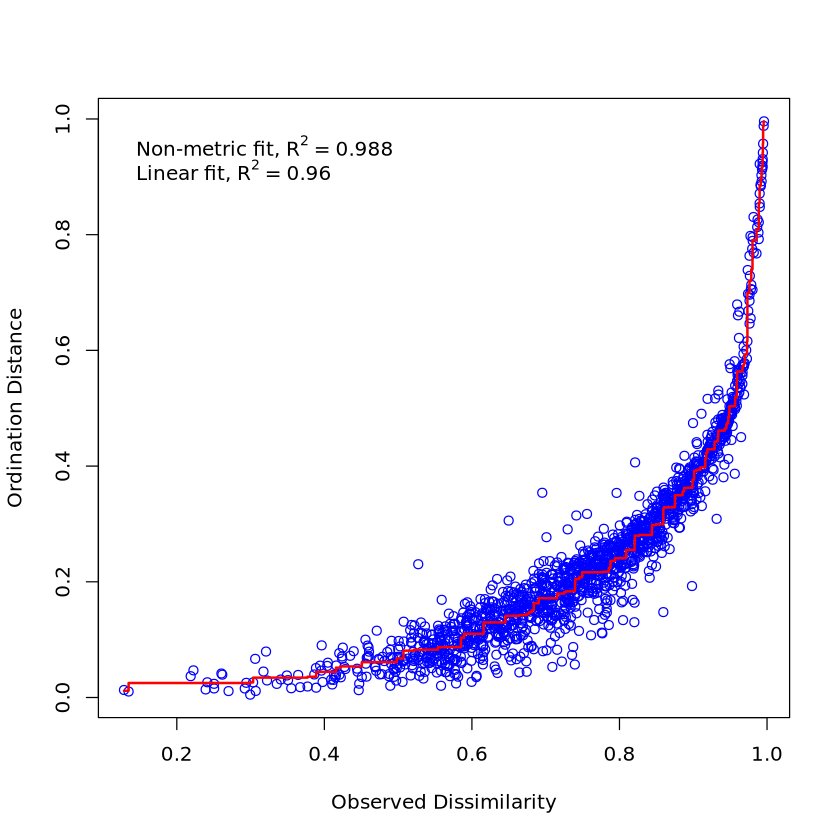

In [15]:
#created the distance matrix (bray curtis) first and then ran metaMDS
bray_dist<- vegdist(genes_filtered_reordered_t, "bray") 
bray<-as.matrix(bray_dist)
write.csv(bray, "bray_distance_matrix.csv")
set.seed(124)
MDS<- metaMDS(bray)
stressplot(MDS)

In [16]:
nmds_scores <- scores(MDS, choices=c(1,2))

In [28]:
write.csv(nmds_scores, file= "nmds_scores_all_genefamilies.csv")

In [17]:
#added a few columns to the scores csv for sample data
plot_scores <- read.csv("nmds_plots_all_genefamilies.csv", header=T)

In [18]:
options(repr.plot.width=12, repr.plot.height=10)

In [14]:
library(RColorBrewer)
library(ggrepel)

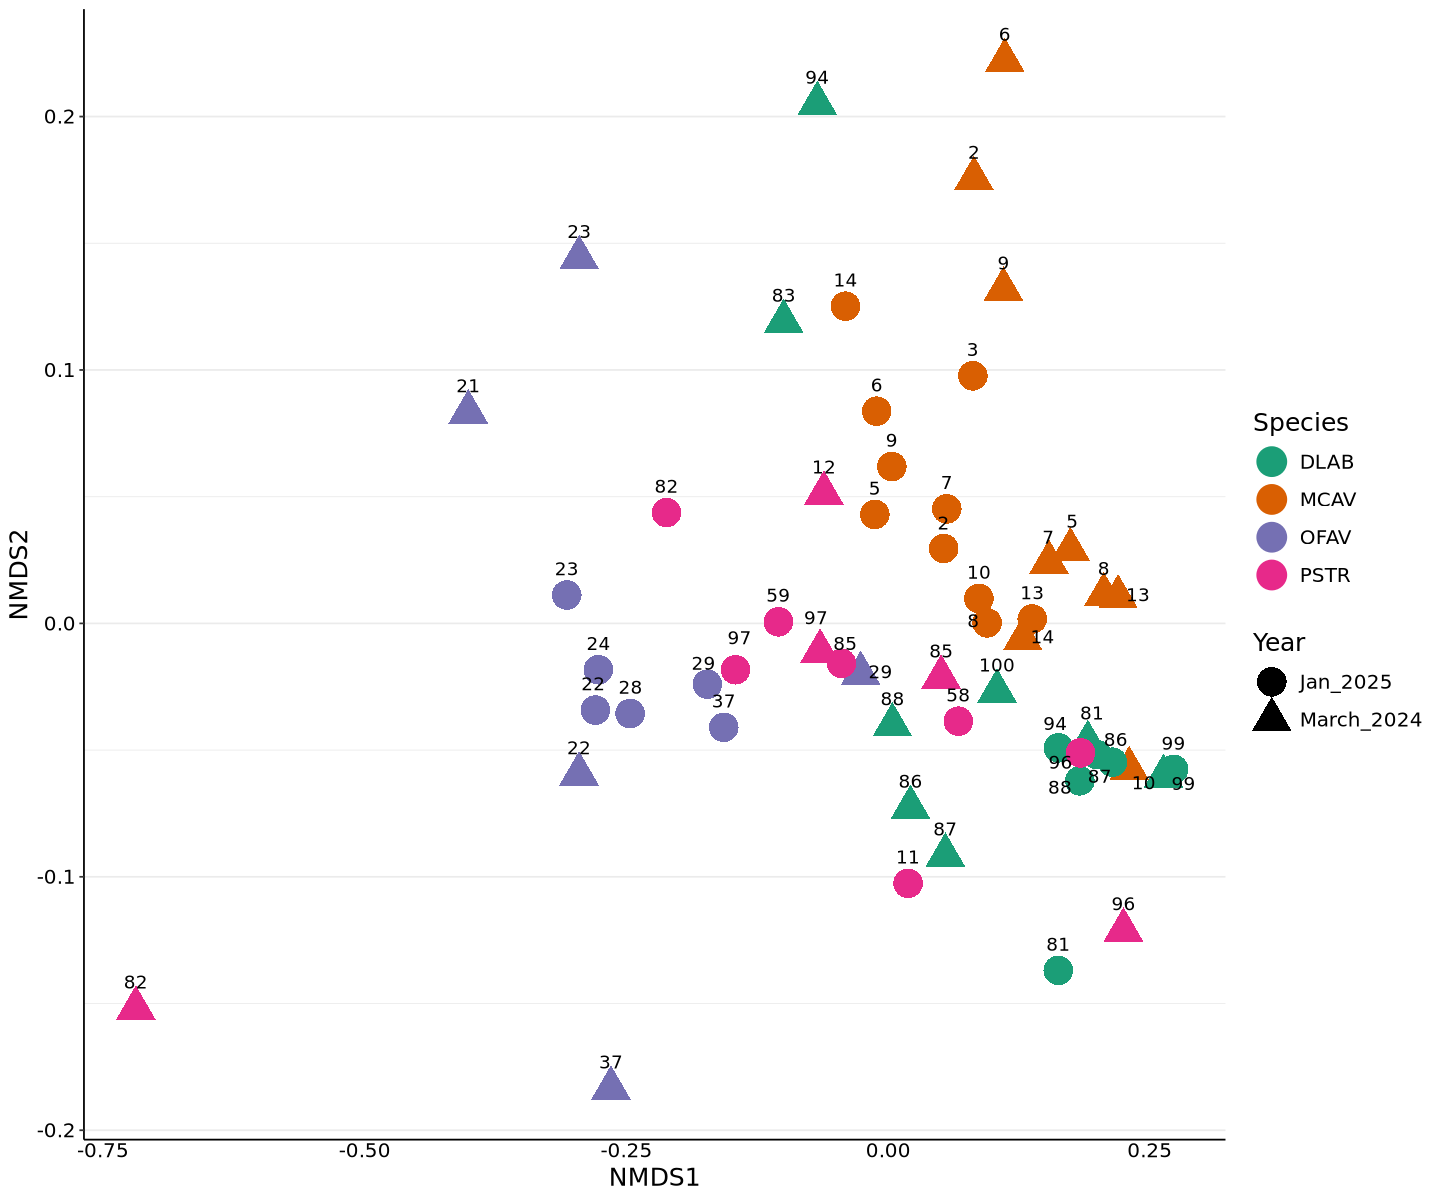

In [19]:
plot <- ggplot(data=plot_scores, aes(x=NMDS1,y=NMDS2, shape= Year, color = Species)) + 
  geom_point(size=8) + scale_color_brewer(palette = "Dark2") +
  #stat_ellipse(level = 0.95, type = "norm") +
  #geom_label(aes(label = Tag), vjust = -1, color = "black") +
  geom_text_repel(aes(label = Tag), vjust = -1.5, color = "black", segment.color= "NA") +
  xlab("NMDS1") + ylab ("NMDS2") +
  theme_bw() +
  theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))
    
plot

In [20]:
ggsave(filename = "bray_all_genes_nmds.png", plot = plot, 
      width = 12,
      height = 10,
      units = "in",
      dpi = 300)

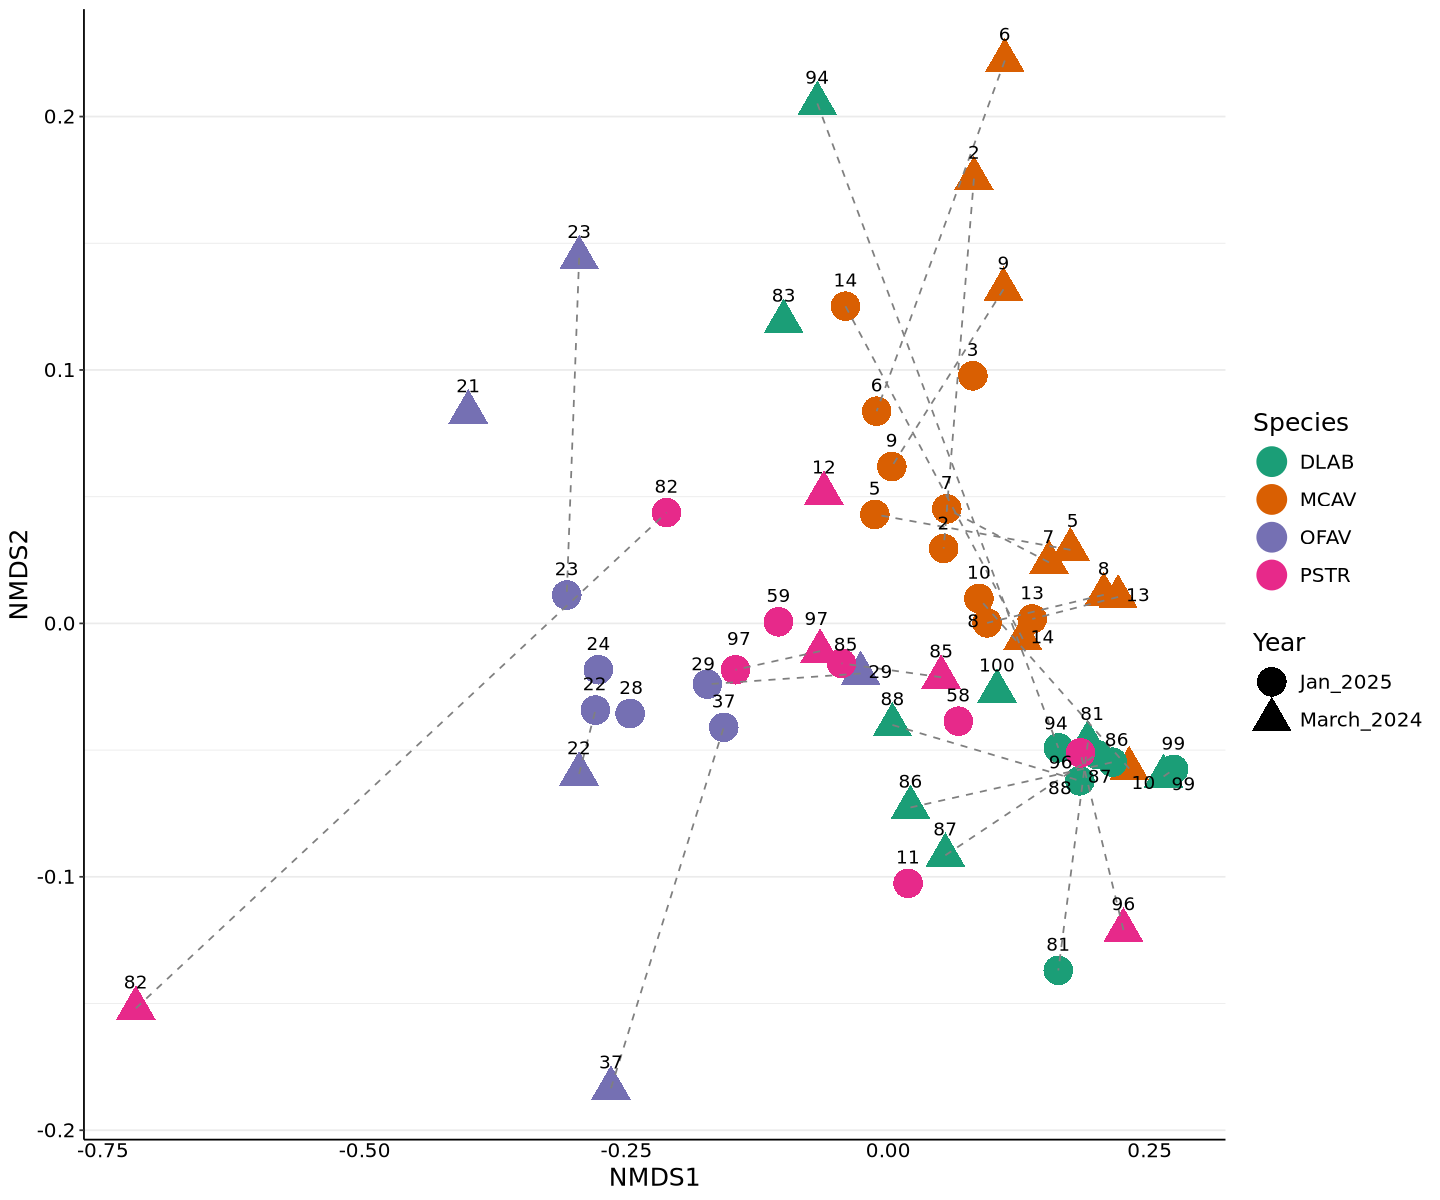

In [21]:
plot2 <- ggplot(data=plot_scores, aes(x=NMDS1,y=NMDS2, shape= Year, color = Species)) + 
  geom_point(size=8) + scale_color_brewer(palette = "Dark2") +
  geom_path(aes(group = Tag), color = "gray50", linetype = "dashed") +
  #stat_ellipse(level = 0.95, type = "norm") +
  #geom_label(aes(label = Tag), vjust = -1, color = "black") +
  geom_text_repel(aes(label = Tag), vjust = -1.5, color = "black", segment.color= "NA") +
  xlab("NMDS1") + ylab ("NMDS2") +
  theme_bw() +
  theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))
    
plot2

In [22]:
ggsave(filename = "bray_paths_all_genes_nmds.png", plot = plot2, 
      width = 12,
      height = 10,
      units = "in",
      dpi = 300)

In [53]:
#plot_scores_filtered <- read.csv("nmds_plot_all_genefamilies.csv", header=T)
#remove 032024_COL_SAN_T5_144_PSTR_S9 just from nmds but I think I need to remove and recalculate distances, will do that below
#plot_scores_filtered <- plot_scores_filtered[!grepl("032024_COL_SAN_T5_144_PSTR_S9", plot_scores_filtered$SampleID), ]

#### Different distance matrices

Run 0 stress 0.1331913 
Run 1 stress 0.1511354 
Run 2 stress 0.1426304 
Run 3 stress 0.1461097 
Run 4 stress 0.1299456 
... New best solution
... Procrustes: rmse 0.04546608  max resid 0.2313144 
Run 5 stress 0.1450156 
Run 6 stress 0.1560936 
Run 7 stress 0.1542751 
Run 8 stress 0.1331915 
Run 9 stress 0.1337994 
Run 10 stress 0.1478534 
Run 11 stress 0.1299456 
... Procrustes: rmse 0.0002421673  max resid 0.001196572 
... Similar to previous best
Run 12 stress 0.1463943 
Run 13 stress 0.1280548 
... New best solution
... Procrustes: rmse 0.03010925  max resid 0.2004653 
Run 14 stress 0.1300268 
Run 15 stress 0.1339189 
Run 16 stress 0.1280548 
... Procrustes: rmse 0.0003002998  max resid 0.001278705 
... Similar to previous best
Run 17 stress 0.1464691 
Run 18 stress 0.1514794 
Run 19 stress 0.1280555 
... Procrustes: rmse 0.0005115402  max resid 0.002327813 
... Similar to previous best
Run 20 stress 0.1419706 
*** Best solution repeated 2 times


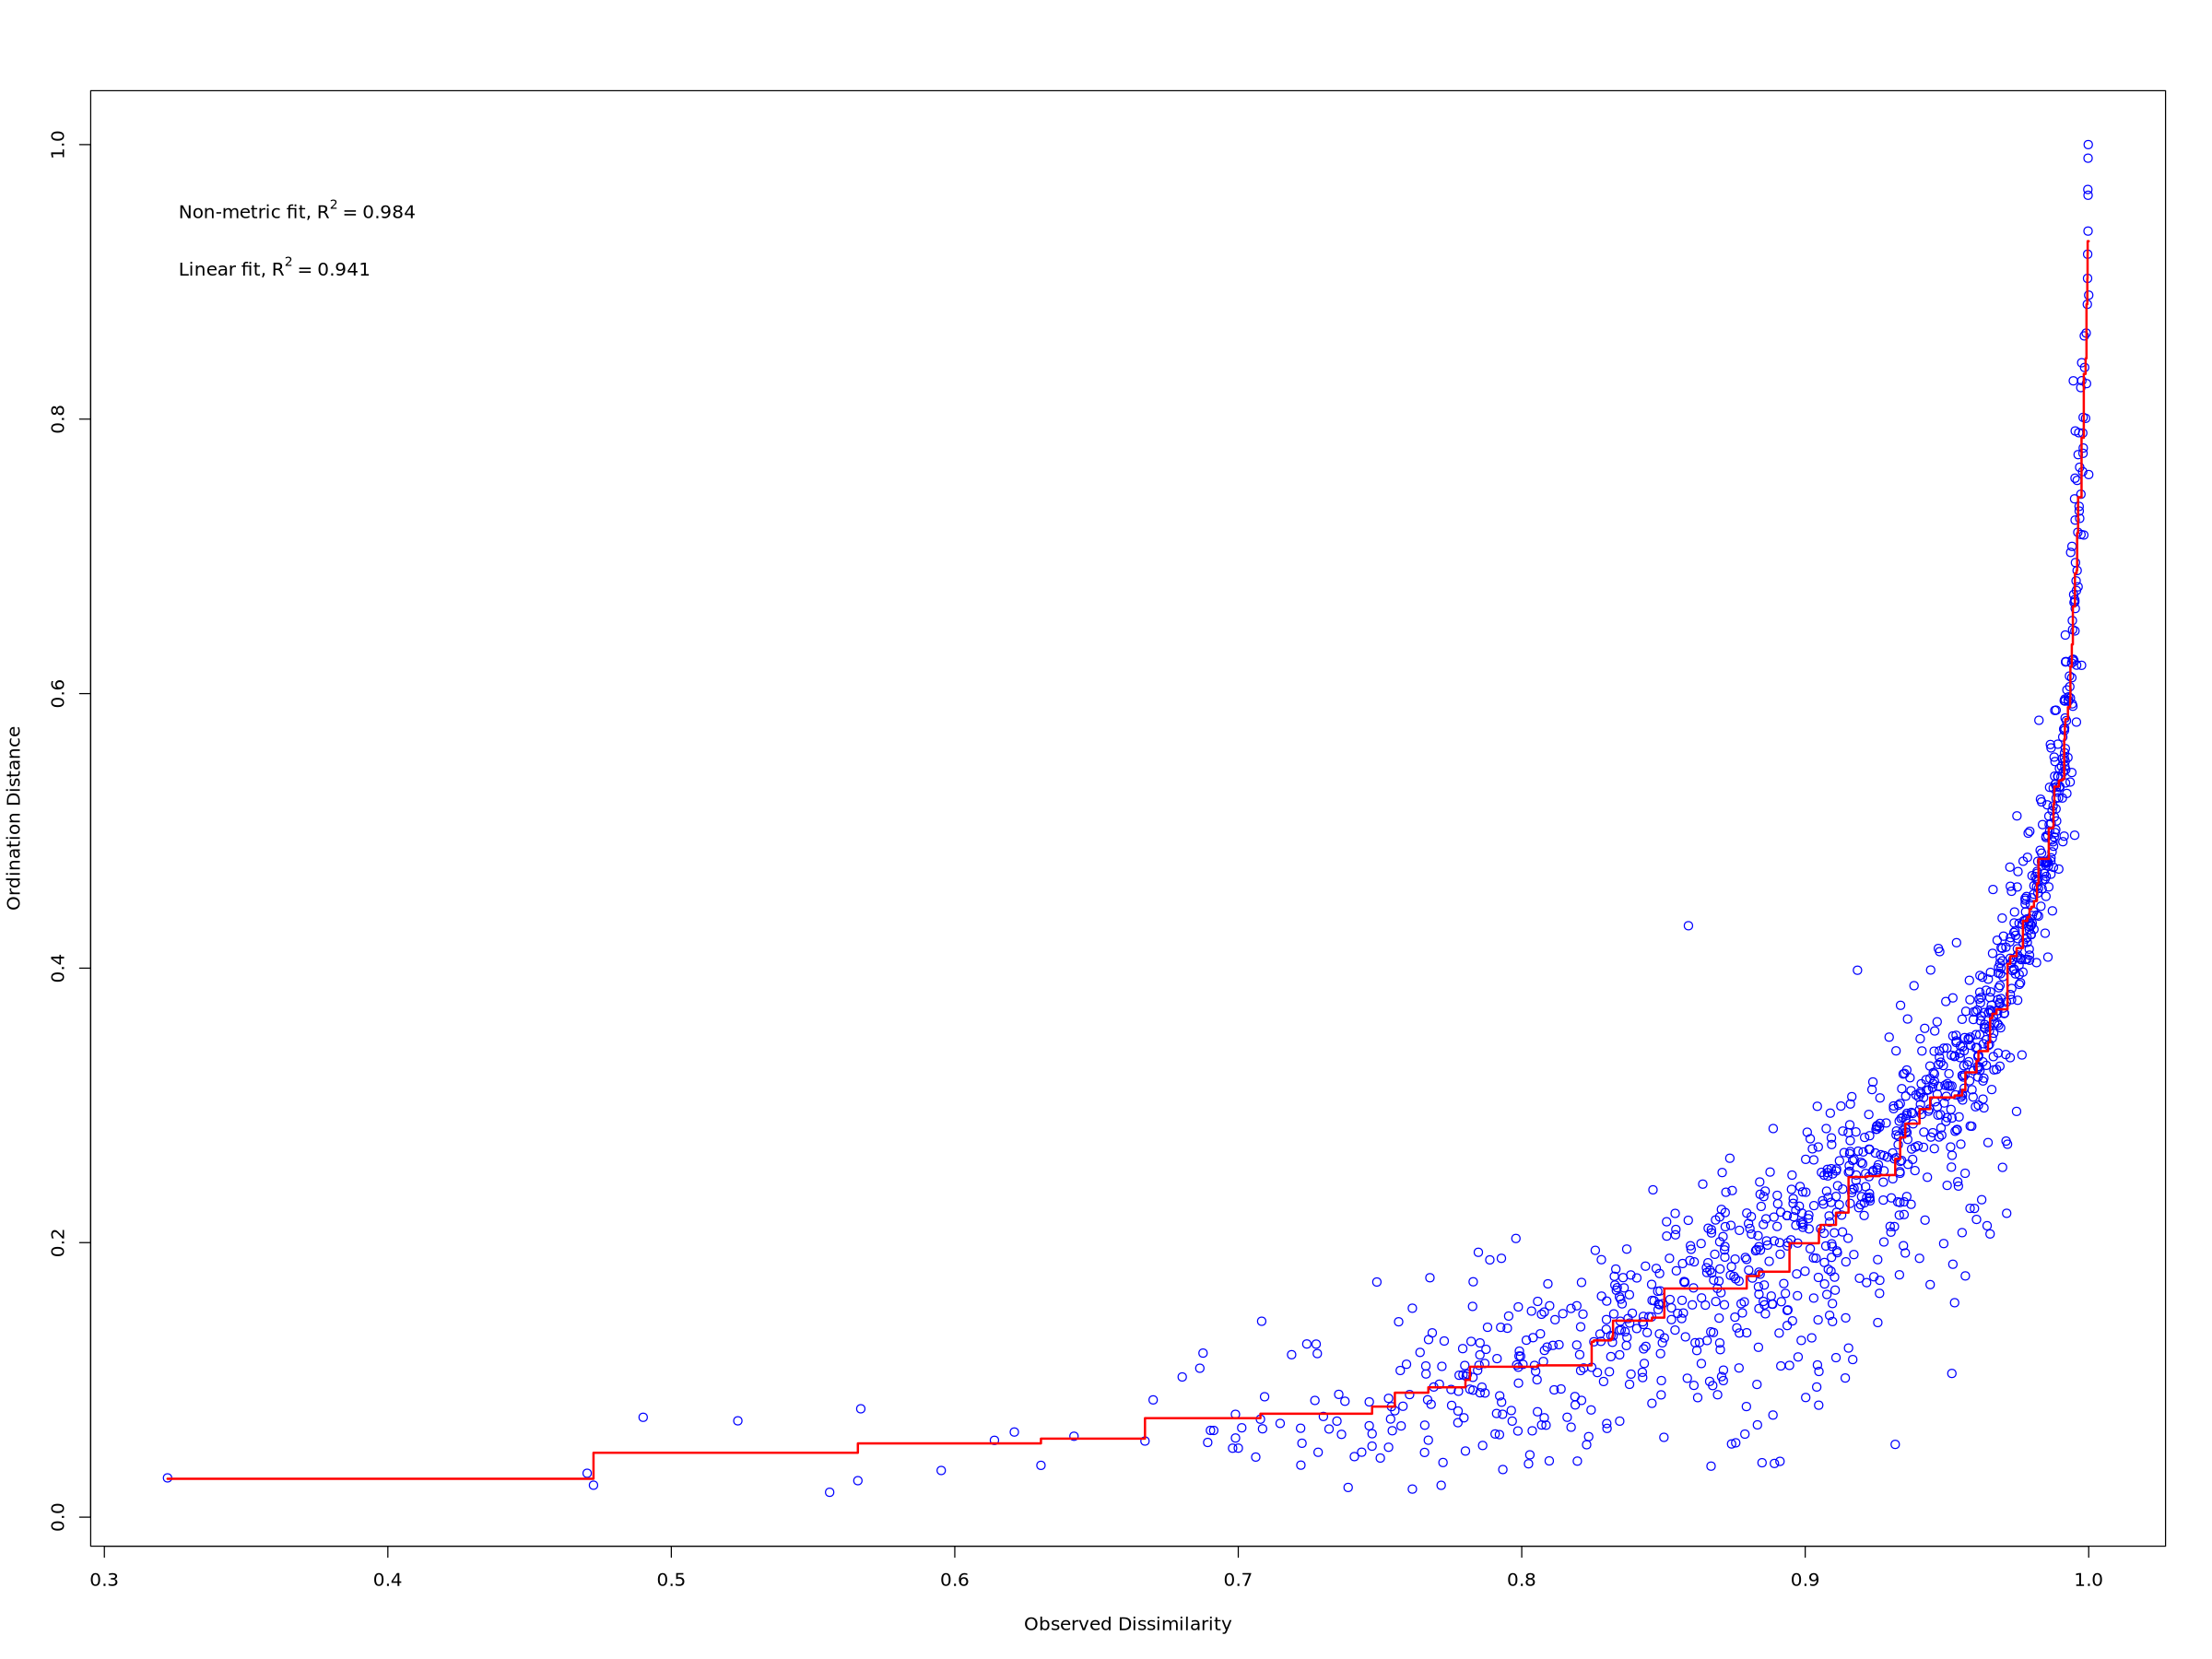

In [35]:
#let's try a different distance matrix
jaccard_dist<- vegdist(genes_filtered_reordered_t, "jaccard") 
jaccard<-as.matrix(jaccard_dist)
write.csv(bray, "jaccard_distance_matrix.csv")
set.seed(124)
MDS_jac<- metaMDS(jaccard)
stressplot(MDS_jac)

In [30]:
nmds_scores_j <- scores(MDS_jac, choices=c(1,2))

In [31]:
write.csv(nmds_scores_j, file= "nmds_scores_jaccard_all_but_0125_pstr_genefamilies.csv")

In [32]:
plot_scores_j <- read.csv("nmds_plot_jaccard_all_but_0125_pstr_genefamilies.csv", header=T)

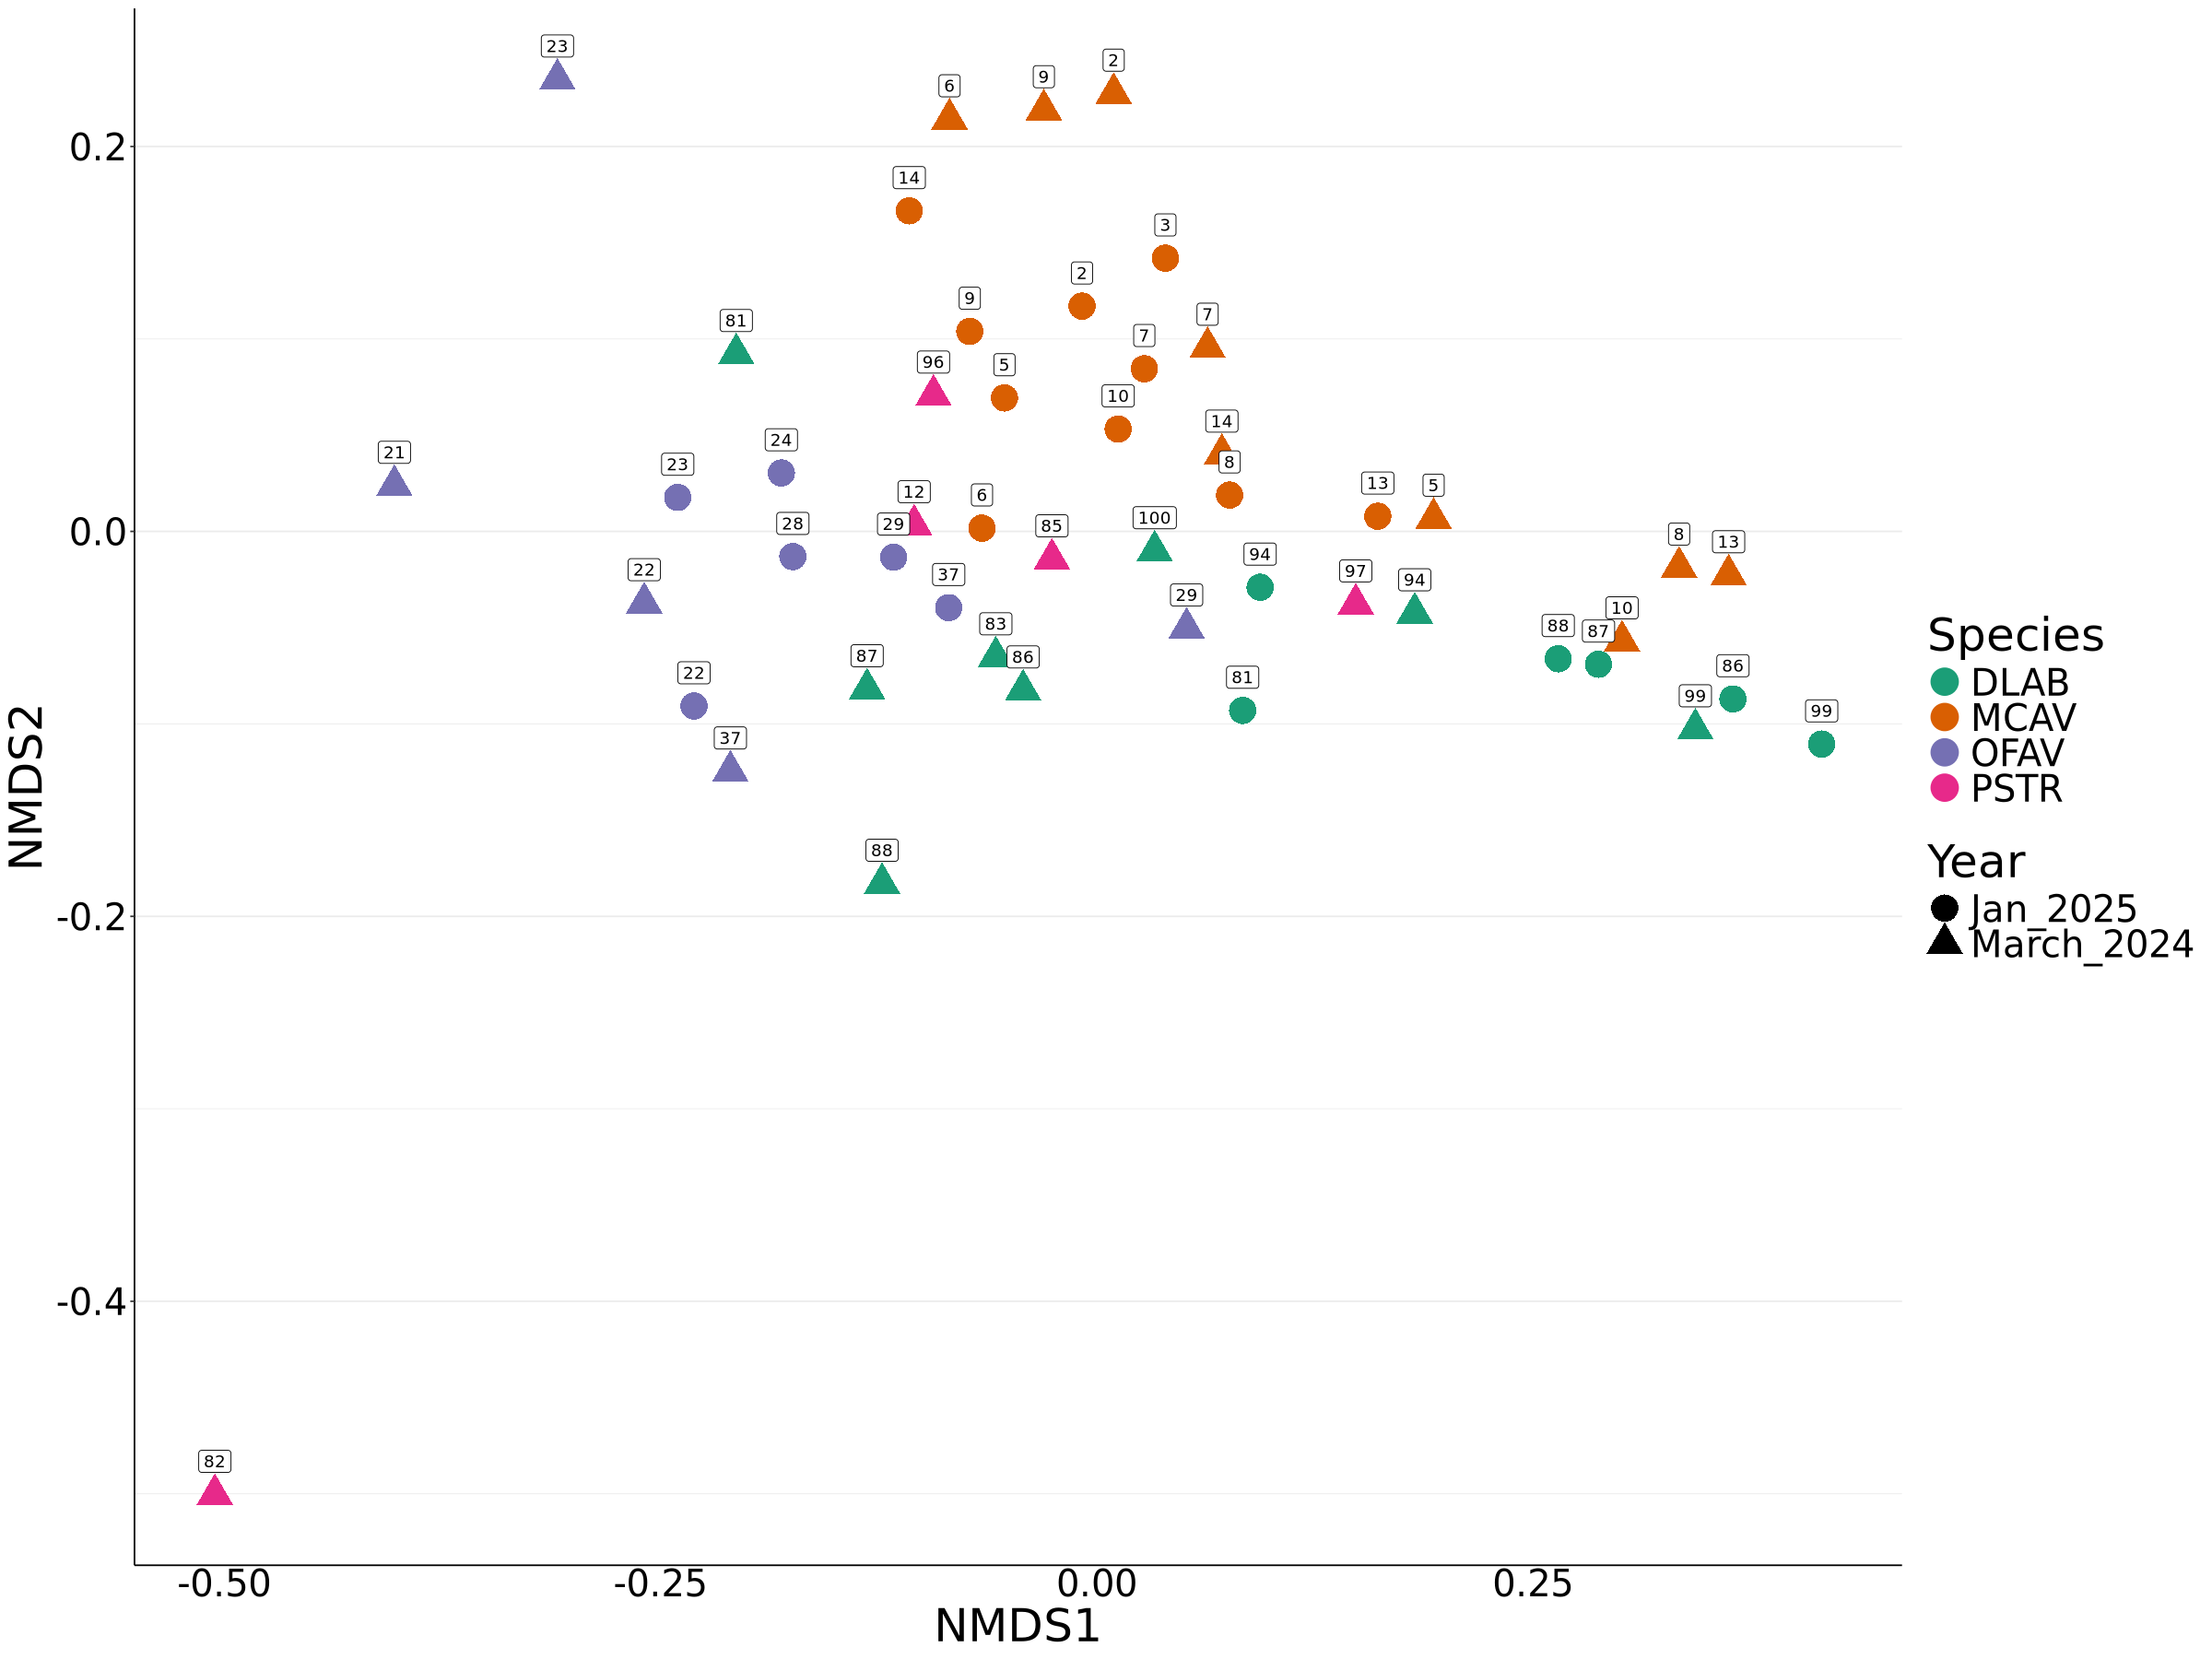

In [33]:
plot2 <- ggplot(data=plot_scores_j, aes(x=NMDS1,y=NMDS2, shape= Year, color = Species)) + 
  geom_point(size=8) + scale_color_brewer(palette = "Dark2") +
  geom_label(aes(label = Tag), vjust = -1, color = "black") +
  xlab("NMDS1") + ylab ("NMDS2") +
  theme_bw() +
  theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 30))
    
plot2

In [ ]:
try another - mayve aitchison but would have to transform the data...

### Heatmap of genes/pathways

In [4]:
#install.packages("pheatmap")

In [76]:
#if (!require("remotes")){
#    install.packages("remotes")
#}
#remotes::install_github("gesistsa/rio")

In [77]:
#if (!require("BiocManager", quietly = TRUE))
#    install.packages("BiocManager")

#BiocManager::install("apeglm")

In [78]:
#install.packages("ggpicrust2")

In [23]:
library(tidyverse)
library(magrittr)
library(pheatmap)
library(RColorBrewer)
#library(rio)
library(DESeq2)
library(ggplot2)
library(apeglm)
library(ggpicrust2)
library(ggh4x)
library(dplyr)
library(tidyr)
library(tibble)


Attaching package: ‘magrittr’


The following object is masked from ‘package:GenomicRanges’:

    subtract


The following object is masked from ‘package:purrr’:

    set_names


The following object is masked from ‘package:tidyr’:

    extract


Loading required package: ggpicrust2

To cite ggpicrust2 in publications use:

Chen Yang, Jiahao Mai, Xuan Cao, Aaron Burberry, Fabio Cominelli, Liangliang Zhang, ggpicrust2: an R package for PICRUSt2 predicted functional profile analysis and visualization, Bioinformatics, Volume 39, Issue 8, August 2023, btad470, https://doi.org/10.1093/bioinformatics/btad470



In [6]:
getwd()

[1] "/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL"

In [24]:
setwd("/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/humann3_functional_analysis_032024_012025/")

In [61]:
head(genes_filtered_reordered) #then remove the gene_family column, use the one that's not indexed

,Gene_Family,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,⋯,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,012025_COL_SAN_T5_587_PSTR_S20,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,0,0,0,9.45823,0,0.00000,0,0,⋯,0,0,0.0000,18.94060,0,0.00000,0,12.0018,0.0000,0
8,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,0,0,0,0.00000,0,5.41724,0,0,⋯,0,0,22.6396,16.10200,0,7.75194,0,0.0000,50.2233,0
10,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0,0,0,0.00000,0,0.00000,0,0,⋯,0,0,0.0000,3.96876,0,0.00000,0,0.0000,0.0000,0
12,1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],0,0,0,0,0.00000,0,5.85221,0,0,⋯,0,0,0.0000,0.00000,0,0.00000,0,0.0000,0.0000,0
14,1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],0,0,0,0,0.00000,0,0.00000,0,0,⋯,0,0,0.0000,0.00000,0,0.00000,0,0.0000,13.8331,0
16,1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0,0,0,0,0.00000,0,0.00000,0,0,⋯,0,0,0.0000,0.00000,0,0.00000,0,0.0000,11.6232,0


In [37]:
#remove the Gene_family column
genes_filtered_reordered_counts <- genes_filtered_reordered[, -1]
head(genes_filtered_reordered_counts)
dim(genes_filtered_reordered_counts)

,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,⋯,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,012025_COL_SAN_T5_587_PSTR_S20,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,0,0,0,0,9.45823,0,0.00000,0,0,0,⋯,0,0,0.0000,18.94060,0,0.00000,0,12.0018,0.0000,0
8,0,0,0,0,0.00000,0,5.41724,0,0,0,⋯,0,0,22.6396,16.10200,0,7.75194,0,0.0000,50.2233,0
10,0,0,0,0,0.00000,0,0.00000,0,0,0,⋯,0,0,0.0000,3.96876,0,0.00000,0,0.0000,0.0000,0
12,0,0,0,0,0.00000,0,5.85221,0,0,0,⋯,0,0,0.0000,0.00000,0,0.00000,0,0.0000,0.0000,0
14,0,0,0,0,0.00000,0,0.00000,0,0,0,⋯,0,0,0.0000,0.00000,0,0.00000,0,0.0000,13.8331,0
16,0,0,0,0,0.00000,0,0.00000,0,0,0,⋯,0,0,0.0000,0.00000,0,0.00000,0,0.0000,11.6232,0


[1] 3405   56

In [38]:
genes_filtered_reordered_counts=as.matrix(genes_filtered_reordered_counts)
head(genes_filtered_reordered_counts)

,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,⋯,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,012025_COL_SAN_T5_587_PSTR_S20,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25
6,0,0,0,0,9.45823,0,0.00000,0,0,0,⋯,0,0,0.0000,18.94060,0,0.00000,0,12.0018,0.0000,0
8,0,0,0,0,0.00000,0,5.41724,0,0,0,⋯,0,0,22.6396,16.10200,0,7.75194,0,0.0000,50.2233,0
10,0,0,0,0,0.00000,0,0.00000,0,0,0,⋯,0,0,0.0000,3.96876,0,0.00000,0,0.0000,0.0000,0
12,0,0,0,0,0.00000,0,5.85221,0,0,0,⋯,0,0,0.0000,0.00000,0,0.00000,0,0.0000,0.0000,0
14,0,0,0,0,0.00000,0,0.00000,0,0,0,⋯,0,0,0.0000,0.00000,0,0.00000,0,0.0000,13.8331,0
16,0,0,0,0,0.00000,0,0.00000,0,0,0,⋯,0,0,0.0000,0.00000,0,0.00000,0,0.0000,11.6232,0


In [39]:
metadata <- read.csv("COL_metadata_012025.csv",header=TRUE) 

In [40]:
options(repr.plot.width=15, repr.plot.height=15)

Using column 'SampleID' as sample identifier

The Sample Names in order from left to right are:

032024_COL_SAN_T5_146_DLAB_S12, 032024_COL_SAN_T5_148_DLAB_S13, 032024_COL_SAN_T5_149_DLAB_S14, 032024_COL_SAN_T5_158_DLAB_S15, 032024_COL_SAN_T5_159_DLAB_S16, 032024_COL_SAN_T5_143_DLAB_S40, 032024_COL_SAN_T5_160_DLAB_S41, 032024_COL_SAN_T5_161_DLAB_S42, 012025_COL_SAN_T5_569_DLAB_S2, 012025_COL_SAN_T5_570_DLAB_S3, 012025_COL_SAN_T5_571_DLAB_S4, 012025_COL_SAN_T5_575_DLAB_S8, 012025_COL_SAN_T5_579_DLAB_S12, 012025_COL_SAN_T5_586_DLAB_S19, 032024_COL_SAN_T5_128_MCAV_S1, 032024_COL_SAN_T5_129_MCAV_S2, 032024_COL_SAN_T5_130_MCAV_S37, 032024_COL_SAN_T5_131_MCAV_S3, 032024_COL_SAN_T5_132_MCAV_S4, 032024_COL_SAN_T5_133_MCAV_S5, 032024_COL_SAN_T5_134_MCAV_S6, 032024_COL_SAN_T5_136_MCAV_S7, 032024_COL_SAN_T5_150_MCAV_S8, 012025_COL_SAN_T5_574_MCAV_S7, 012025_COL_SAN_T5_578_MCAV_S11, 012025_COL_SAN_T5_581_MCAV_S14, 012025_COL_SAN_T5_583_MCAV_S16, 012025_COL_SAN_T5_588_MCAV_S21, 012025_COL_SAN_T5_58

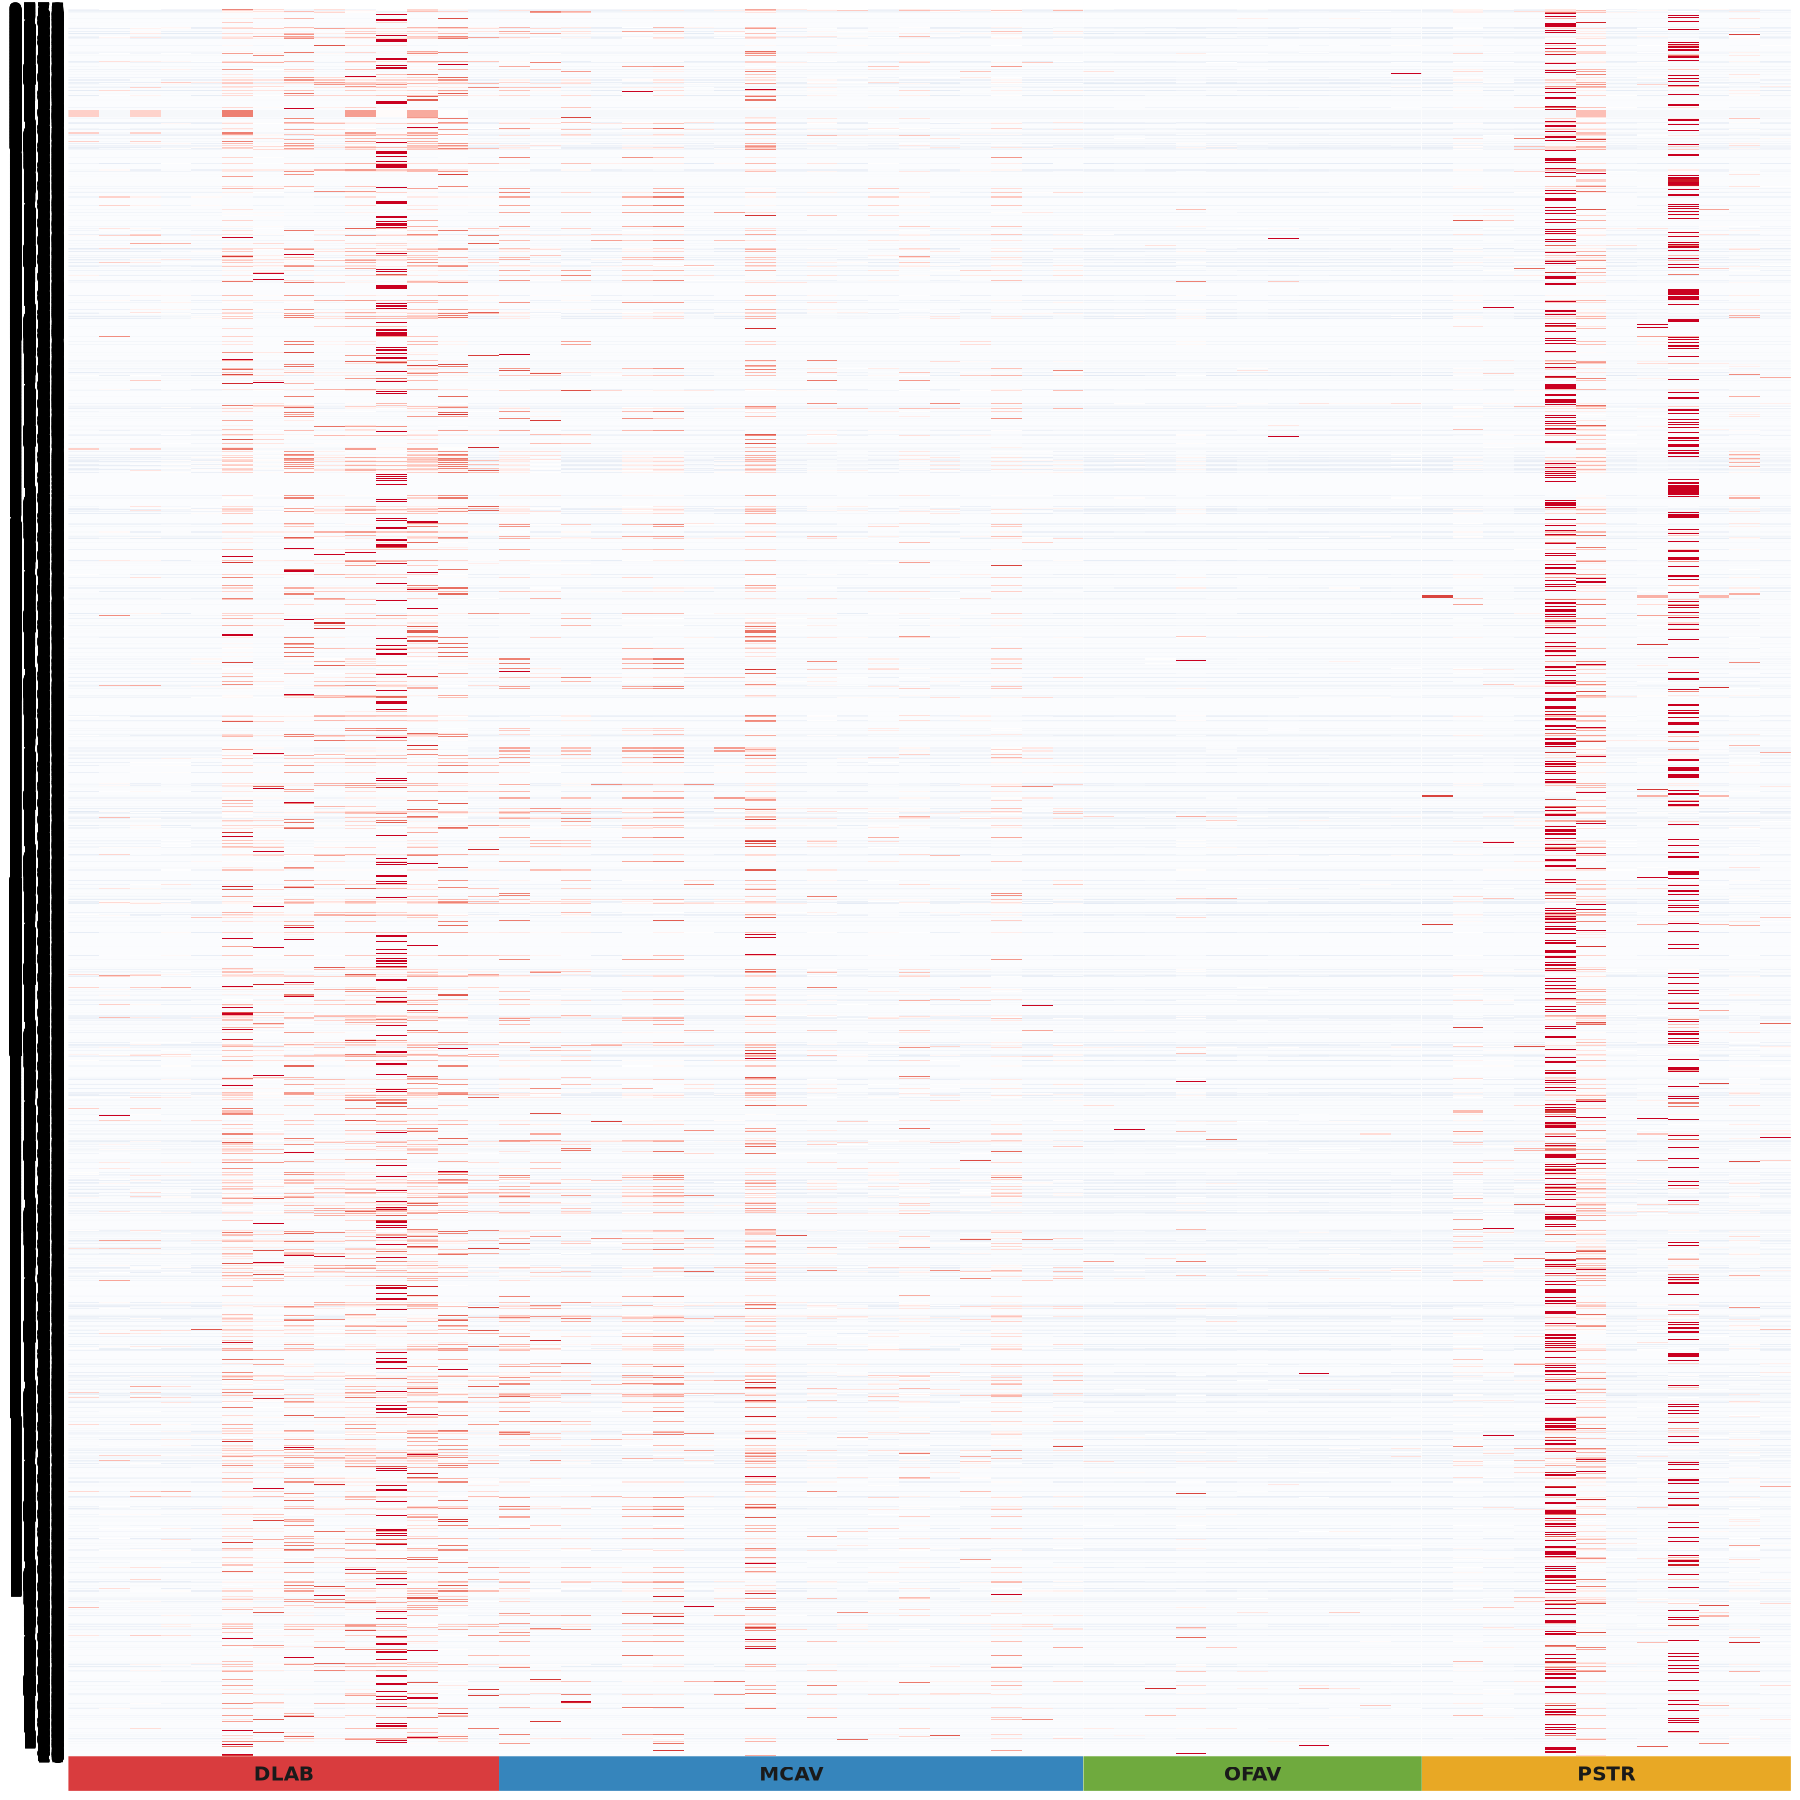

In [45]:
plot1 <- pathway_heatmap(genes_filtered_reordered_counts, metadata, "Species")
plot1

In [41]:
#calculate z-score 
mat_z <- t(scale(t(genes_filtered_reordered_counts)))

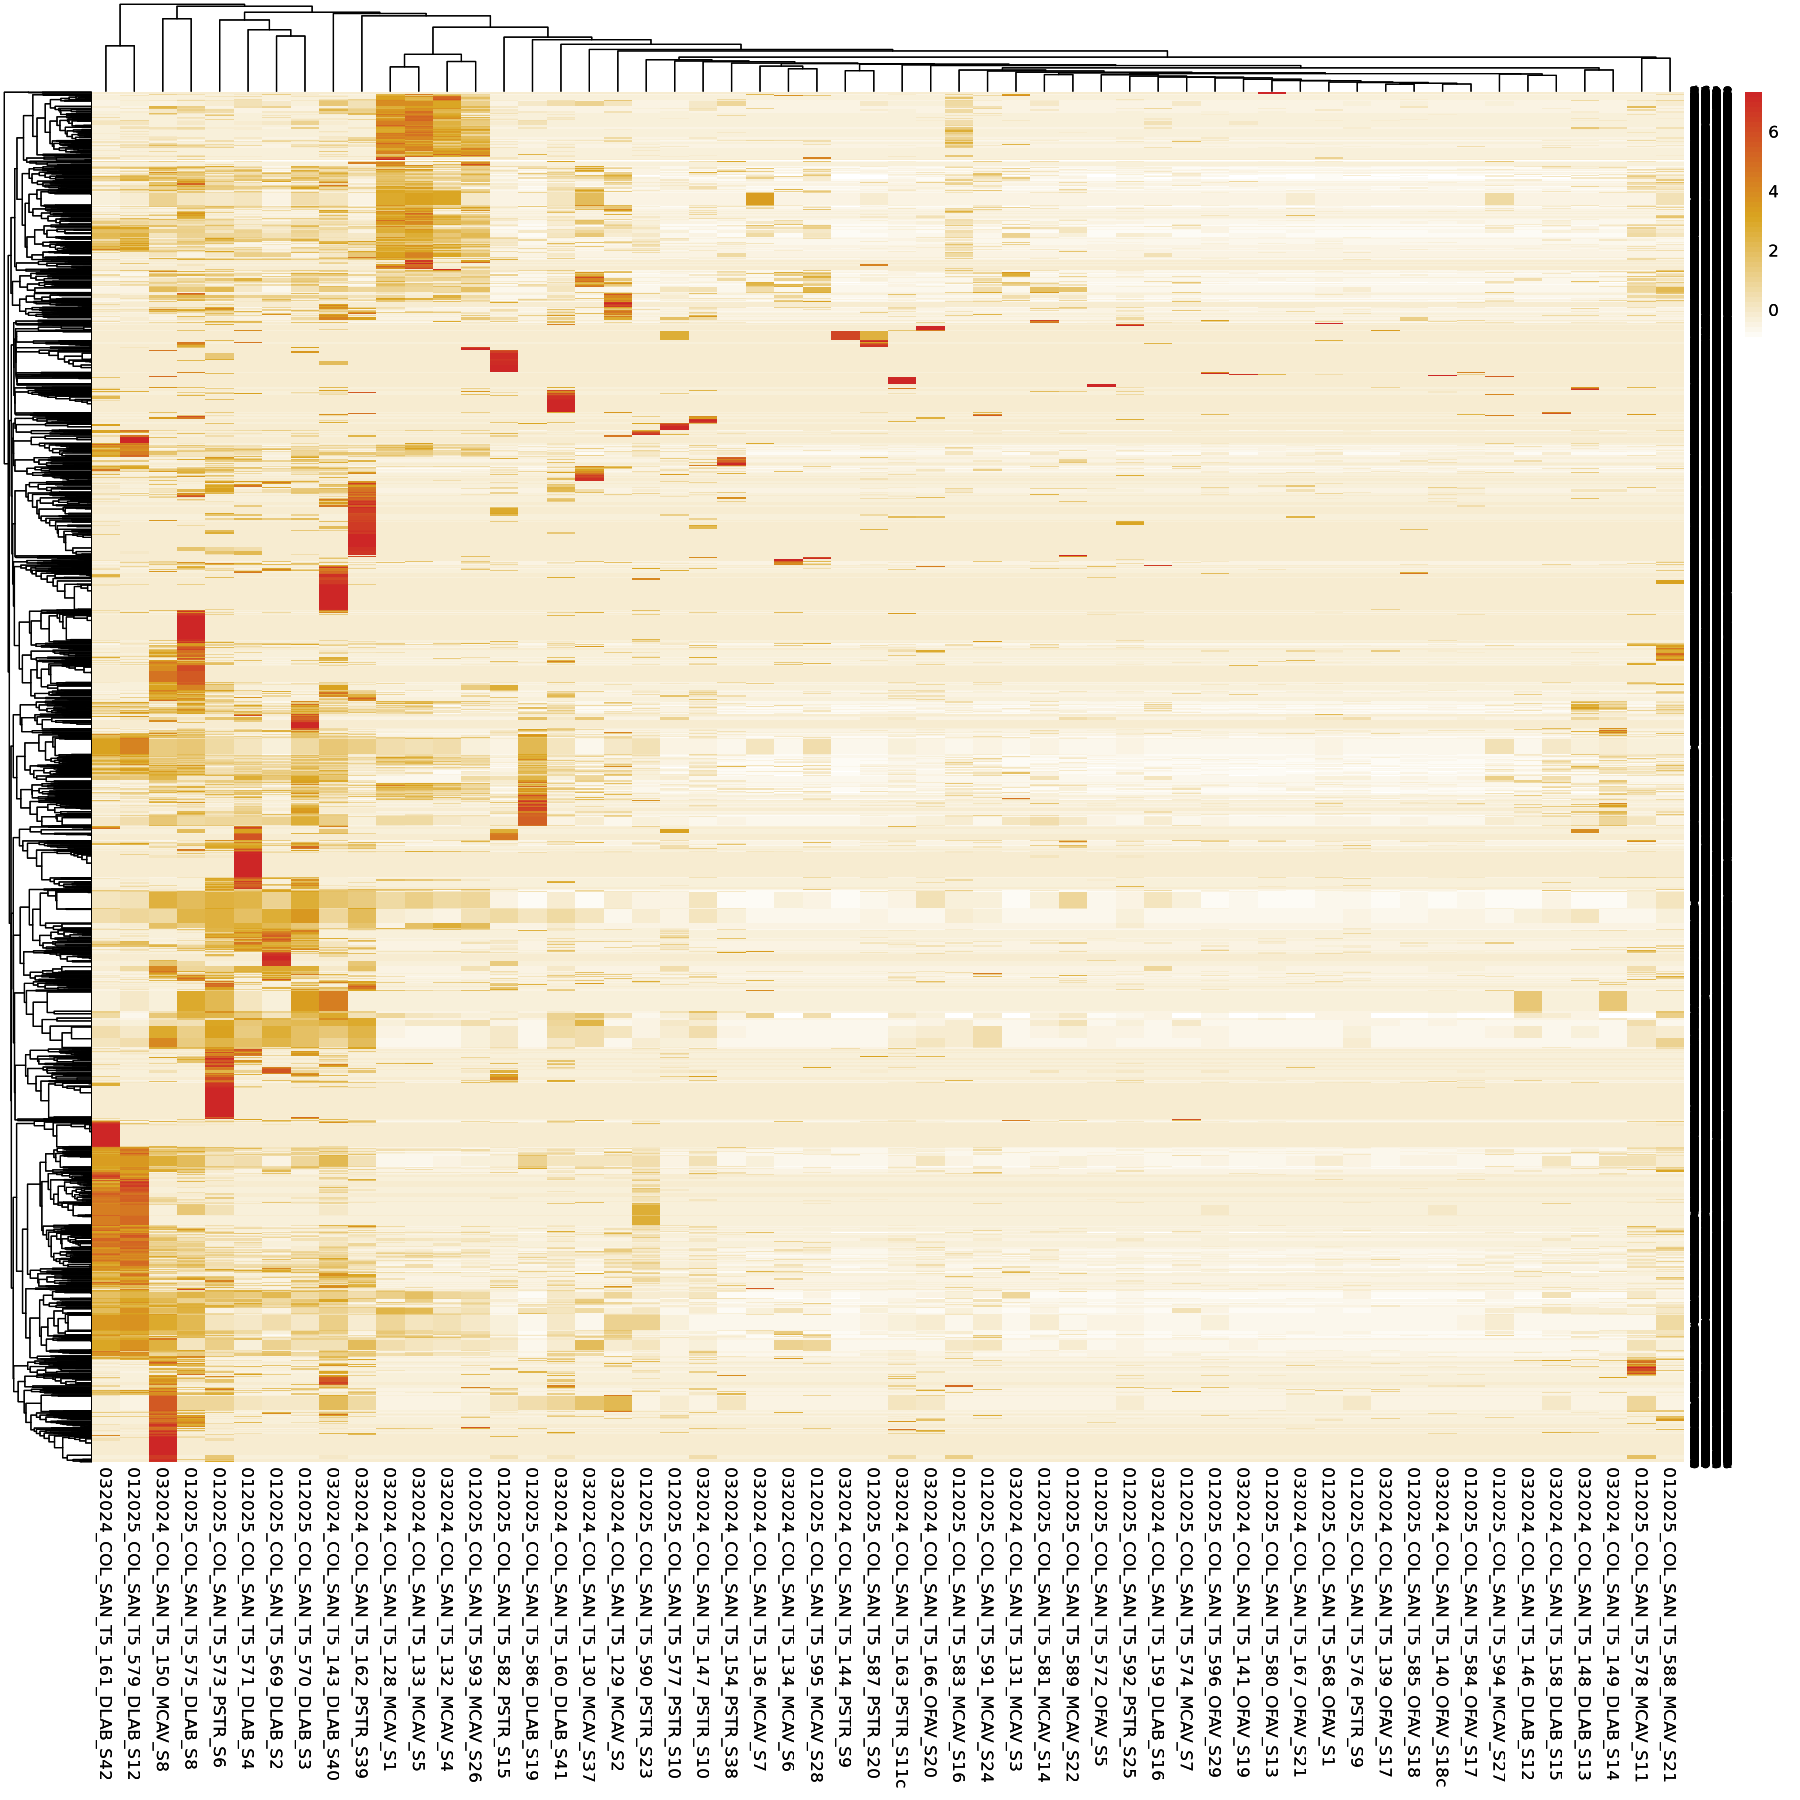

In [45]:
all_genes_plot <- pheatmap(mat_z, 
         cluster_rows = TRUE, 
         cluster_cols = TRUE,
         scale = "none", # Already Z-scored if used mat_z, or use scale="row" on unscaled mat_filtered
         color = colorRampPalette(c("white", "goldenrod", "firebrick3"))(50))
all_genes_plot

In [55]:
gene_totals <- rowSums(genes_filtered_reordered_counts)

In [56]:
#filter for top 75 percentile
#q75 <- quantile( rowVars(genes_filtered_reordered_counts), .75)
q75 <- quantile(gene_totals, probs = 0.75)
head(q75)

75% 
1398.218

#### let's remove OFAVS and recalculate z-score (do ofavs separately)

In [69]:
genes_filtered_reordered=as.matrix(genes_filtered_reordered)
head(genes_filtered_reordered)

,Gene_Family,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,⋯,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,012025_COL_SAN_T5_587_PSTR_S20,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0.00000,0.00000,0.00000,0.00000,9.45823,0.00000,0.00000,0.00000,0.00000,⋯,0.00000,0.00000,0.00000,18.94060,0.00000,0.00000,0.00000,12.00180,0.00000,0.00000
8,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,5.41724,0.00000,0.00000,⋯,0.00000,0.00000,22.63960,16.10200,0.00000,7.75194,0.00000,0.00000,50.22330,0.00000
10,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,⋯,0.00000,0.00000,0.00000,3.96876,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
12,1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,5.85221,0.00000,0.00000,⋯,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
14,1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,⋯,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,13.83310,0.00000
16,1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,⋯,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,11.62320,0.00000


In [79]:
#removing OFAV columns
write.csv(genes_filtered_reordered, file="genes_filtered_reordered.csv")

In [117]:
genes_filtered_reordered_no_ofavs <- read.csv("genes_filtered_reordered_no_ofavs.csv")
dim(genes_filtered_reordered_no_ofavs)

[1] 3405   46

In [118]:
#index gene_family_row
row.names(genes_filtered_reordered_no_ofavs) <- genes_filtered_reordered_no_ofavs$Gene_Family
genes_filtered_reordered_no_ofavs$Gene_Family <- NULL
#remove the Gene_family column
#genes_filtered_reordered_no_ofavs <- genes_filtered_reordered_no_ofavs[, -1]
names(genes_filtered_reordered_no_ofavs) <- sub("^X", "", names(genes_filtered_reordered_no_ofavs))
head(genes_filtered_reordered_no_ofavs)

,032024_COL_SAN_T5_128_MCAV_S1,032024_COL_SAN_T5_129_MCAV_S2,032024_COL_SAN_T5_130_MCAV_S37,032024_COL_SAN_T5_131_MCAV_S3,032024_COL_SAN_T5_132_MCAV_S4,032024_COL_SAN_T5_133_MCAV_S5,032024_COL_SAN_T5_134_MCAV_S6,032024_COL_SAN_T5_136_MCAV_S7,032024_COL_SAN_T5_150_MCAV_S8,012025_COL_SAN_T5_574_MCAV_S7,⋯,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,012025_COL_SAN_T5_587_PSTR_S20,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],118.323,0,89.4167,0,122.716,127.047,0,134.447,55.04680,0,⋯,0,0,0.0000,18.94060,0,0.00000,0,12.0018,0.0000,0
1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0.000,0,0.0000,0,0.000,0.000,0,0.000,2.82153,0,⋯,0,0,22.6396,16.10200,0,7.75194,0,0.0000,50.2233,0
1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0.000,0,0.0000,0,0.000,0.000,0,0.000,8.27379,0,⋯,0,0,0.0000,3.96876,0,0.00000,0,0.0000,0.0000,0
1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],0.000,0,0.0000,0,0.000,0.000,0,0.000,0.00000,0,⋯,0,0,0.0000,0.00000,0,0.00000,0,0.0000,0.0000,0
1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],0.000,0,0.0000,0,0.000,0.000,0,0.000,0.00000,0,⋯,0,0,0.0000,0.00000,0,0.00000,0,0.0000,13.8331,0
1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0.000,0,0.0000,0,0.000,0.000,0,0.000,0.00000,0,⋯,0,0,0.0000,0.00000,0,0.00000,0,0.0000,11.6232,0


In [119]:
#remove rows with zero sum
genes_filtered_reordered_no_ofavs_num <- genes_filtered_reordered_no_ofavs[rowSums(genes_filtered_reordered_no_ofavs) != 0, ]
dim(genes_filtered_reordered_no_ofavs_num)
head(genes_filtered_reordered_no_ofavs_num)

[1] 3382   45

,032024_COL_SAN_T5_128_MCAV_S1,032024_COL_SAN_T5_129_MCAV_S2,032024_COL_SAN_T5_130_MCAV_S37,032024_COL_SAN_T5_131_MCAV_S3,032024_COL_SAN_T5_132_MCAV_S4,032024_COL_SAN_T5_133_MCAV_S5,032024_COL_SAN_T5_134_MCAV_S6,032024_COL_SAN_T5_136_MCAV_S7,032024_COL_SAN_T5_150_MCAV_S8,012025_COL_SAN_T5_574_MCAV_S7,⋯,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,012025_COL_SAN_T5_587_PSTR_S20,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],118.323,0,89.4167,0,122.716,127.047,0,134.447,55.04680,0,⋯,0,0,0.0000,18.94060,0,0.00000,0,12.0018,0.0000,0
1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0.000,0,0.0000,0,0.000,0.000,0,0.000,2.82153,0,⋯,0,0,22.6396,16.10200,0,7.75194,0,0.0000,50.2233,0
1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0.000,0,0.0000,0,0.000,0.000,0,0.000,8.27379,0,⋯,0,0,0.0000,3.96876,0,0.00000,0,0.0000,0.0000,0
1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],0.000,0,0.0000,0,0.000,0.000,0,0.000,0.00000,0,⋯,0,0,0.0000,0.00000,0,0.00000,0,0.0000,13.8331,0
1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0.000,0,0.0000,0,0.000,0.000,0,0.000,0.00000,0,⋯,0,0,0.0000,0.00000,0,0.00000,0,0.0000,11.6232,0
1.1.1.268-RXN: (expasy) 2-(R)-hydroxypropyl-CoM dehydrogenase [1.1.1.268],0.000,0,0.0000,0,0.000,0.000,0,0.000,0.00000,0,⋯,0,0,0.0000,0.00000,0,0.00000,0,0.0000,0.0000,0


In [120]:
#calculate z-score 
mat_z_no_ofavs <- t(scale(t(genes_filtered_reordered_no_ofavs_num)))

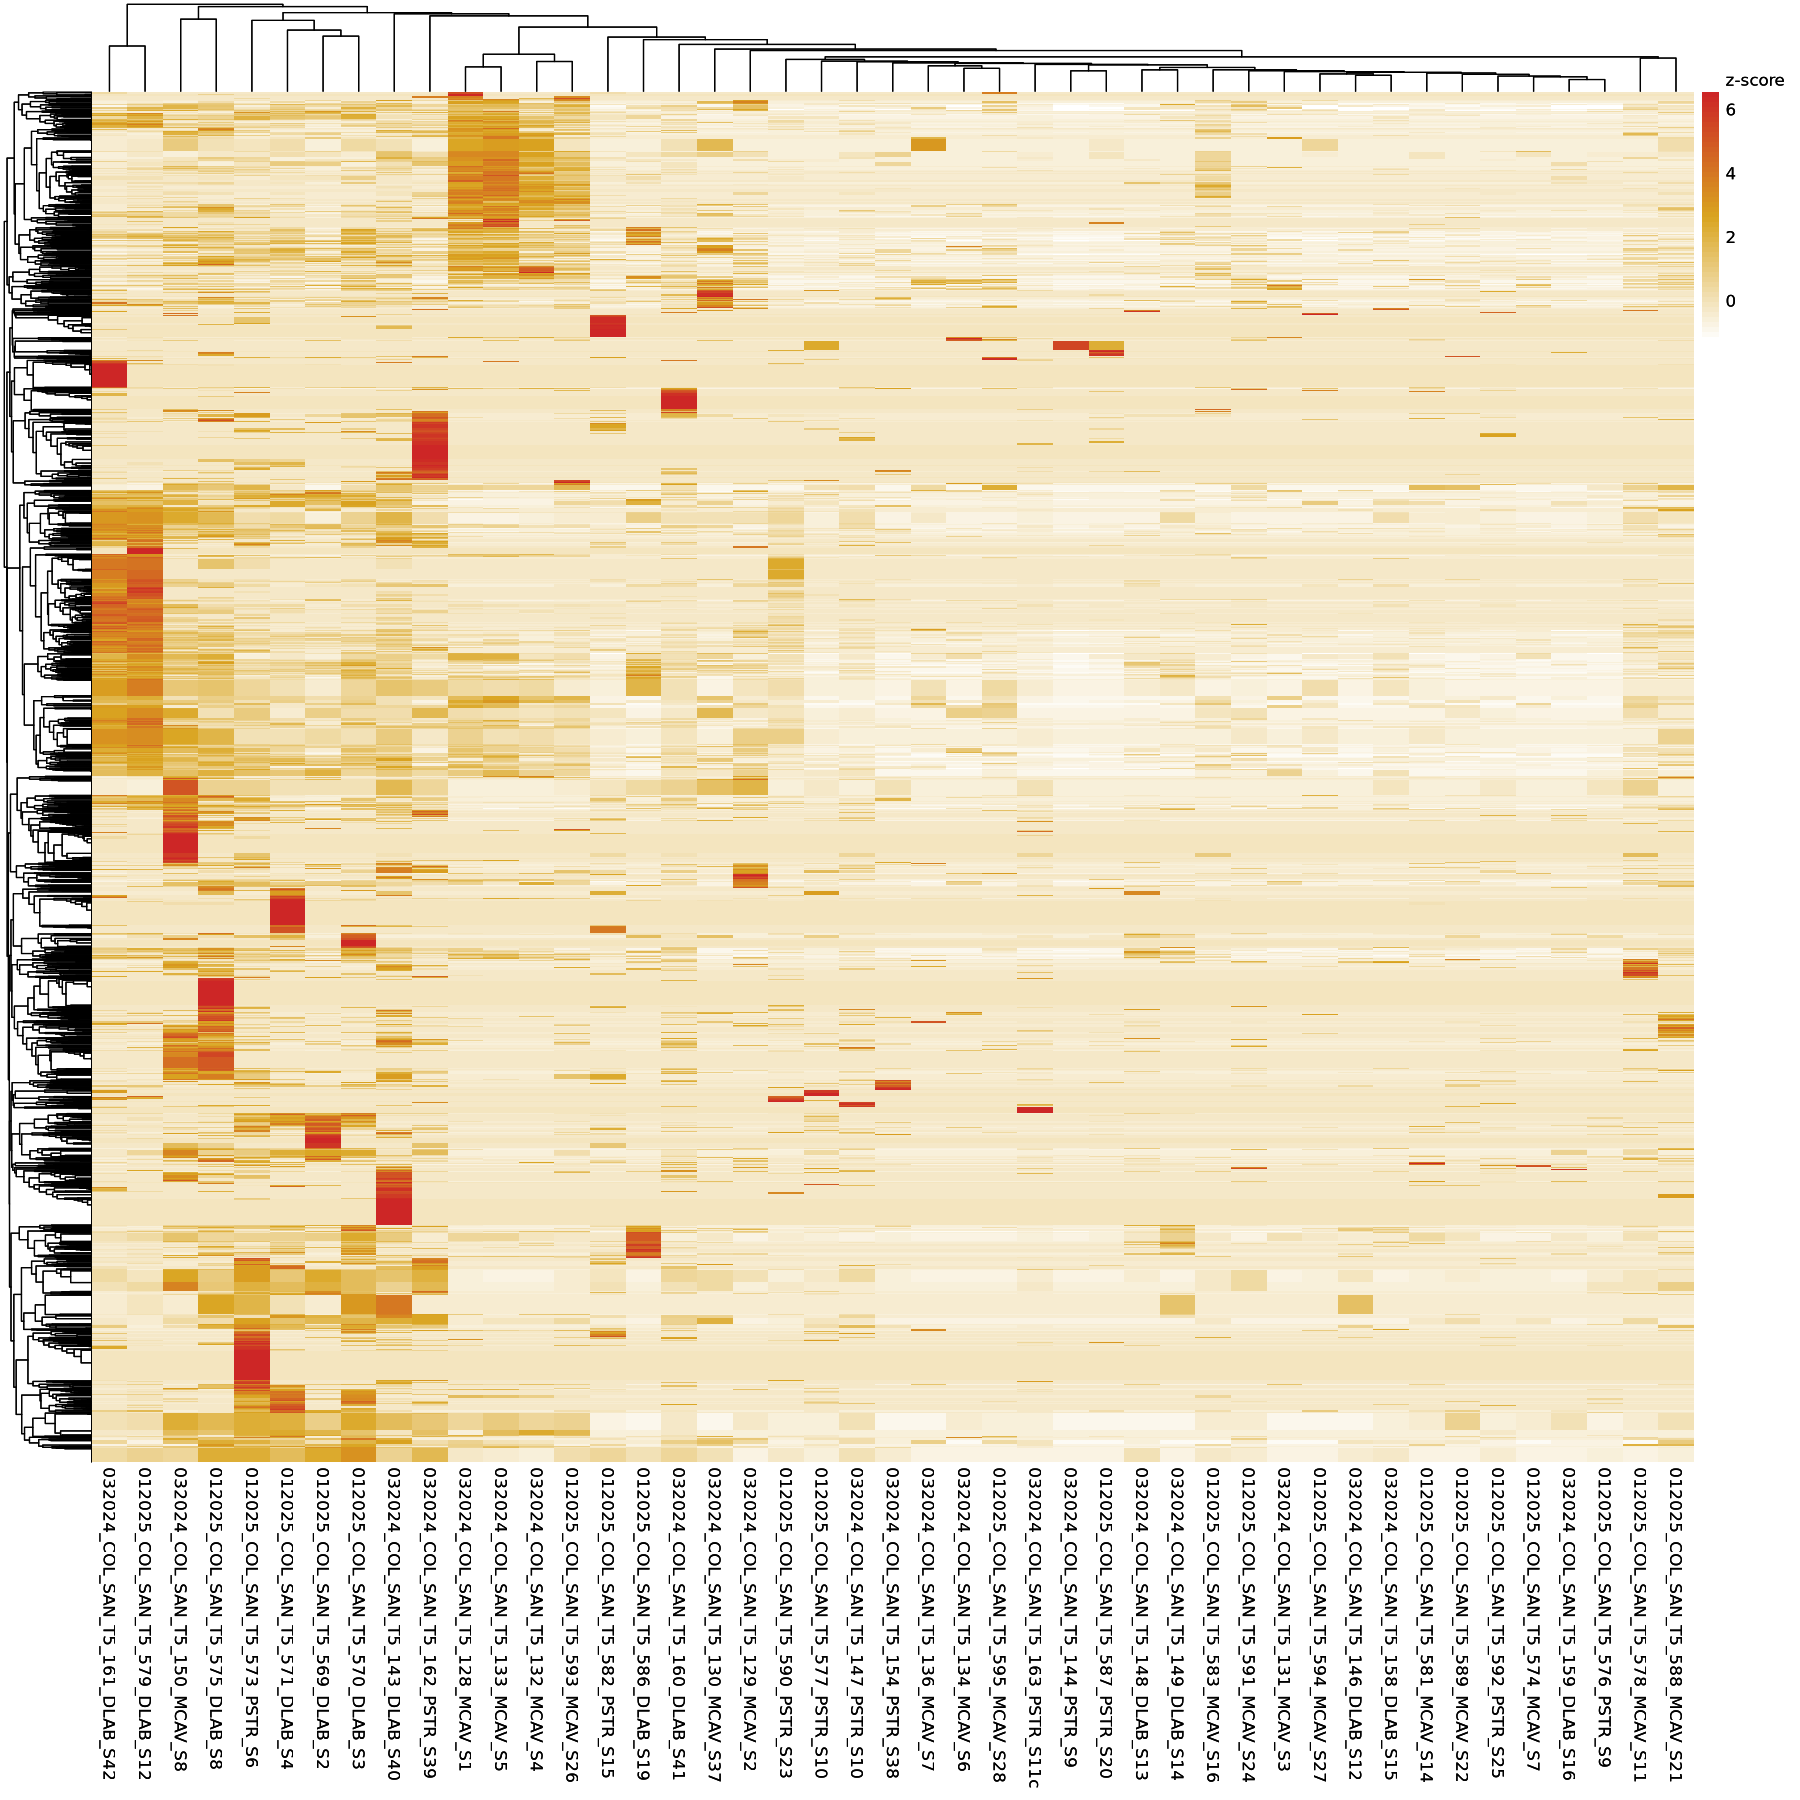

In [136]:
genes_plot_dlab_pstr_mcav <- pheatmap(mat_z_no_ofavs, 
         cluster_rows = TRUE, 
         cluster_cols = TRUE,
         show_rownames = FALSE,
         legend_breaks = c(0, 2, 4, 6, max(mat_z_no_ofavs)),
         legend_labels = c("0", "2", "4", "6", "z-score\n"),
         legend=TRUE,
         scale = "none", # Already Z-scored if used mat_z, or use scale="row" on unscaled mat_filtered
         color = colorRampPalette(c("white", "goldenrod", "firebrick3"))(50))
genes_plot_dlab_pstr_mcav

In [127]:
ggsave(filename = "dlab_pstr_mcav_gene_heatmap.png", plot = genes_plot_dlab_pstr_mcav, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)

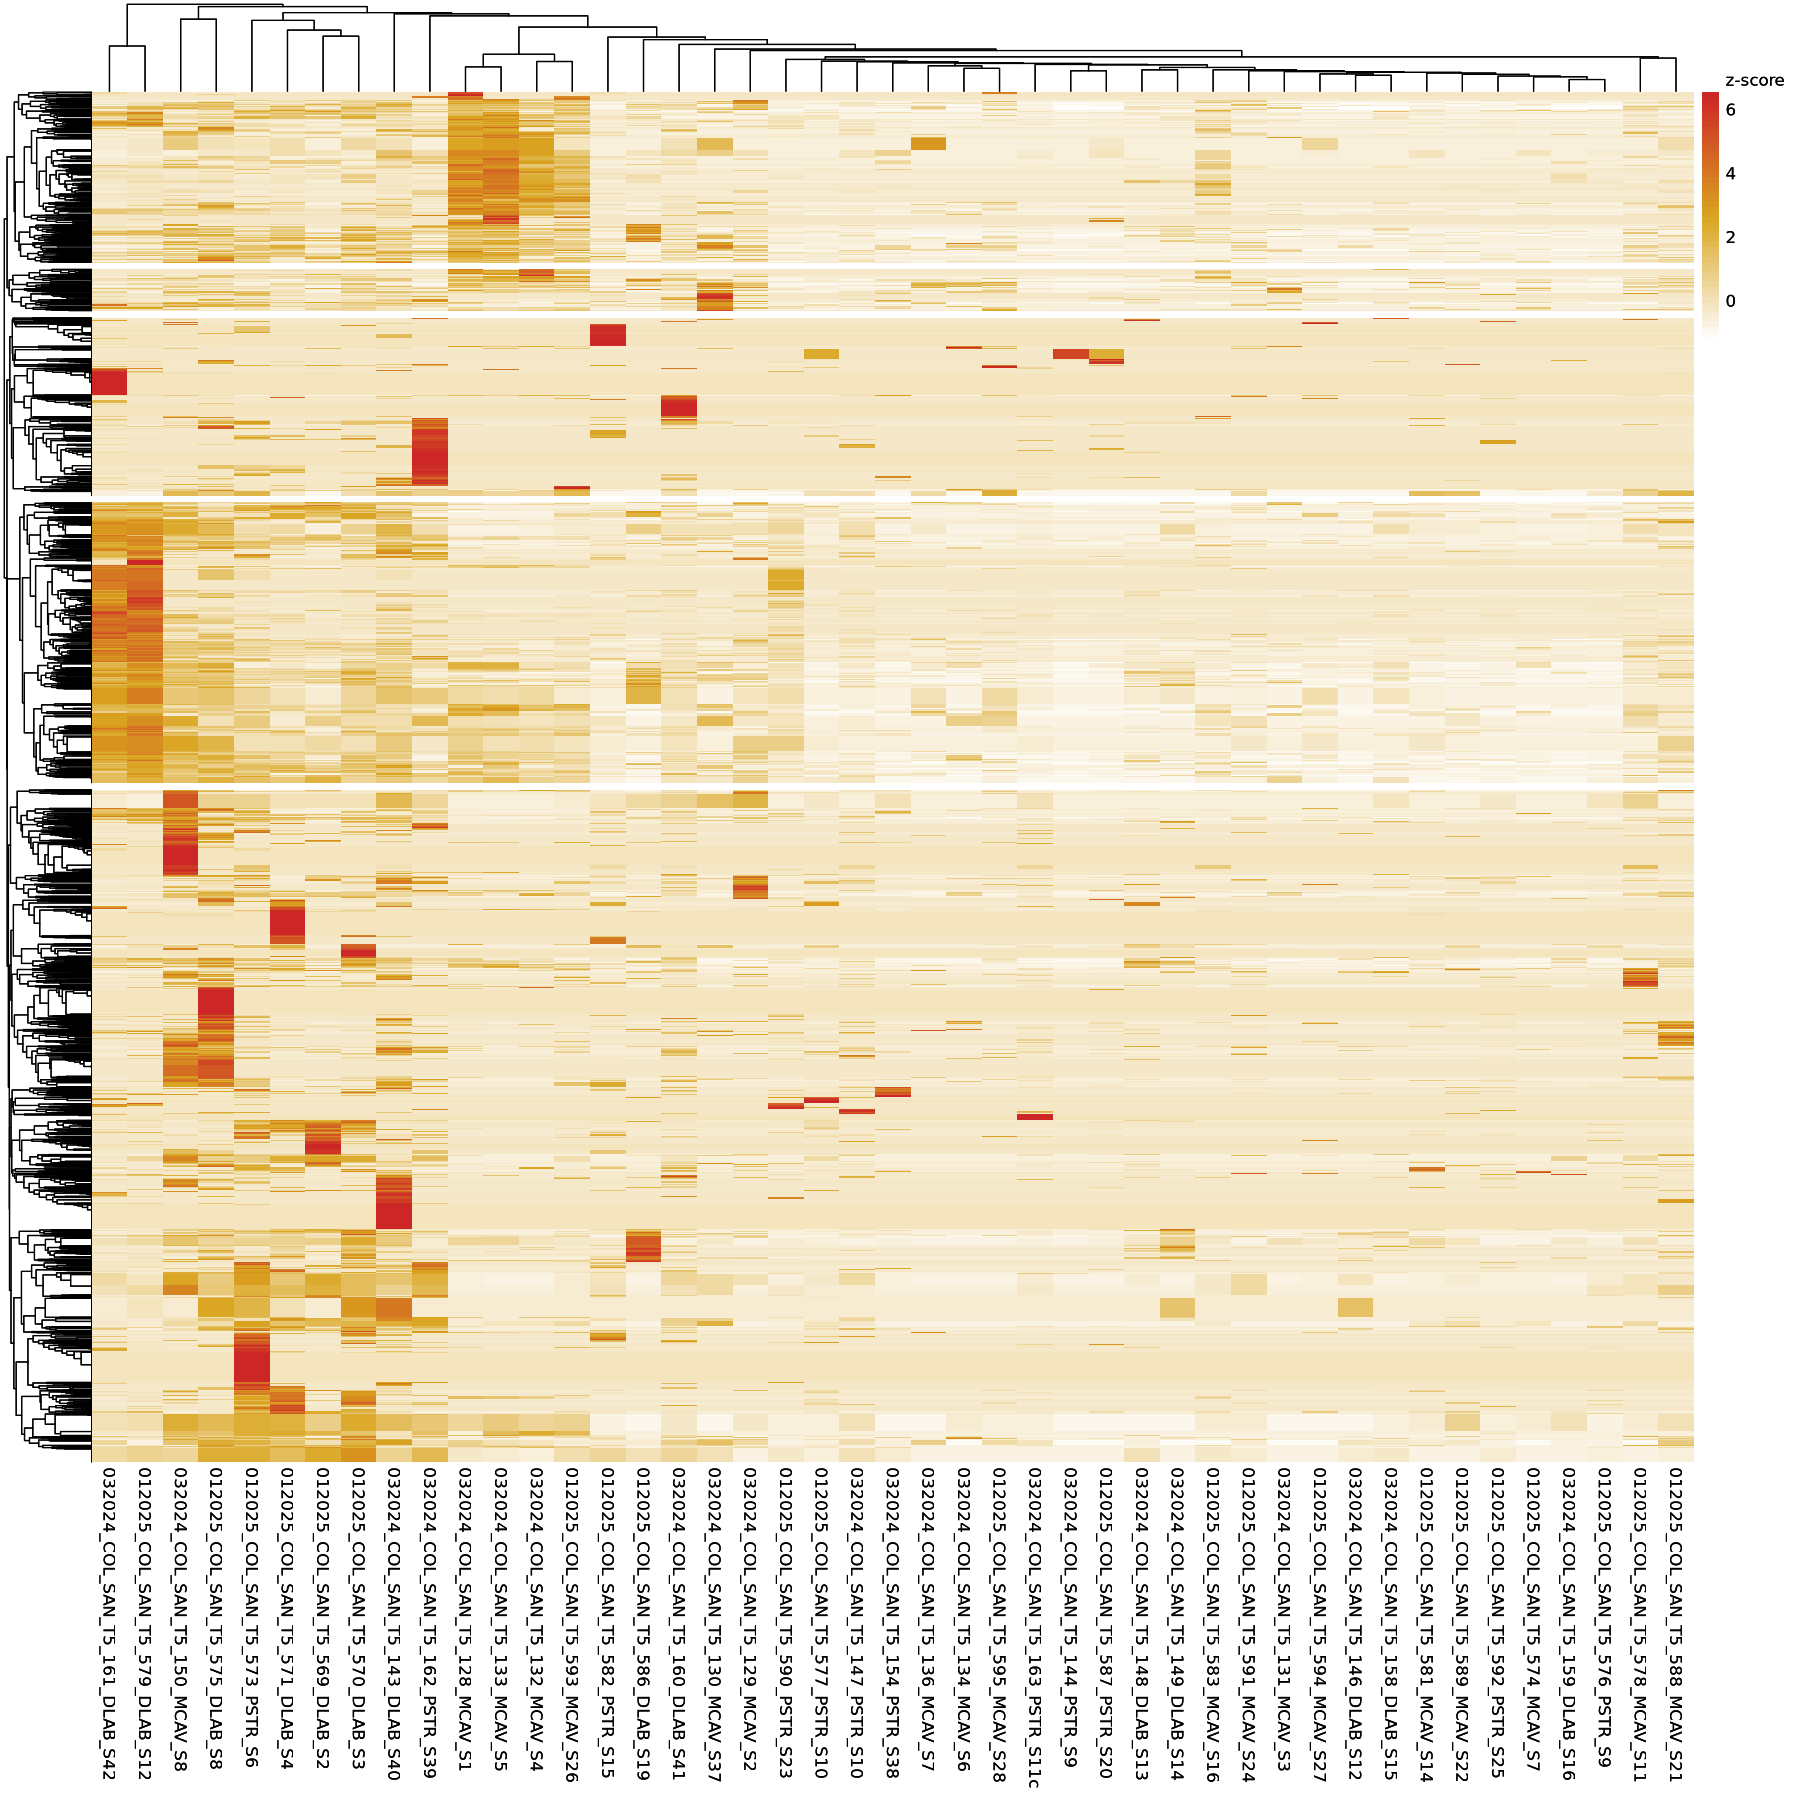

In [132]:
genes_plot_dlab_pstr_mcav_obj <- pheatmap(mat_z_no_ofavs, cutree_rows = 5,
                                         show_rownames = FALSE,
                                         legend_breaks = c(0, 2, 4, 6, max(mat_z_no_ofavs)),
                                         legend_labels = c("0", "2", "4", "6", "z-score\n"),
                                         legend=TRUE,
                                         scale = "none",
                                         color = colorRampPalette(c("white", "goldenrod", "firebrick3"))(50))
genes_plot_dlab_pstr_mcav_obj

In [142]:
ggsave(filename = "dlab_pstr_mcav_gene_heatmap_clusters.png", plot = genes_plot_dlab_pstr_mcav_obj, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)

In [163]:
ggsave(filename = "dlab_pstr_mcav_gene_heatmap_clusters_small.png", plot = genes_plot_dlab_pstr_mcav_obj, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

In [137]:
row_clusters <- cutree(genes_plot_dlab_pstr_mcav_obj$tree_row, k = 5)

In [140]:
cluster_1_genes <- names(row_clusters[row_clusters == 1])
cluster_2_genes <- names(row_clusters[row_clusters == 2])
cluster_3_genes <- names(row_clusters[row_clusters == 3])
cluster_4_genes <- names(row_clusters[row_clusters == 4])
cluster_5_genes <- names(row_clusters[row_clusters == 5])

In [141]:
write.csv(cluster_1_genes, file= "/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/humann3_functional_analysis_032024_012025/heatmap_clusters/no_ofav_cluster1.csv")
write.csv(cluster_2_genes, file= "/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/humann3_functional_analysis_032024_012025/heatmap_clusters/no_ofav_cluster2.csv")
write.csv(cluster_3_genes, file= "/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/humann3_functional_analysis_032024_012025/heatmap_clusters/no_ofav_cluster3.csv")
write.csv(cluster_4_genes, file= "/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/humann3_functional_analysis_032024_012025/heatmap_clusters/no_ofav_cluster4.csv")
write.csv(cluster_5_genes, file= "/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/humann3_functional_analysis_032024_012025/heatmap_clusters/no_ofav_cluster5.csv")


In [146]:
row_indices <- genes_plot_dlab_pstr_mcav_obj$tree_row$order

In [145]:
final_clusters <- data.frame(
  Item = names(row_clusters),
  Cluster = row_clusters
)

In [147]:
final_clusters_ordered <- final_clusters[row_indices, ]

In [148]:
write.csv(final_clusters_ordered, file="/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/humann3_functional_analysis_032024_012025/heatmap_clusters/final_clusters_ordered_no_ofav.csv")

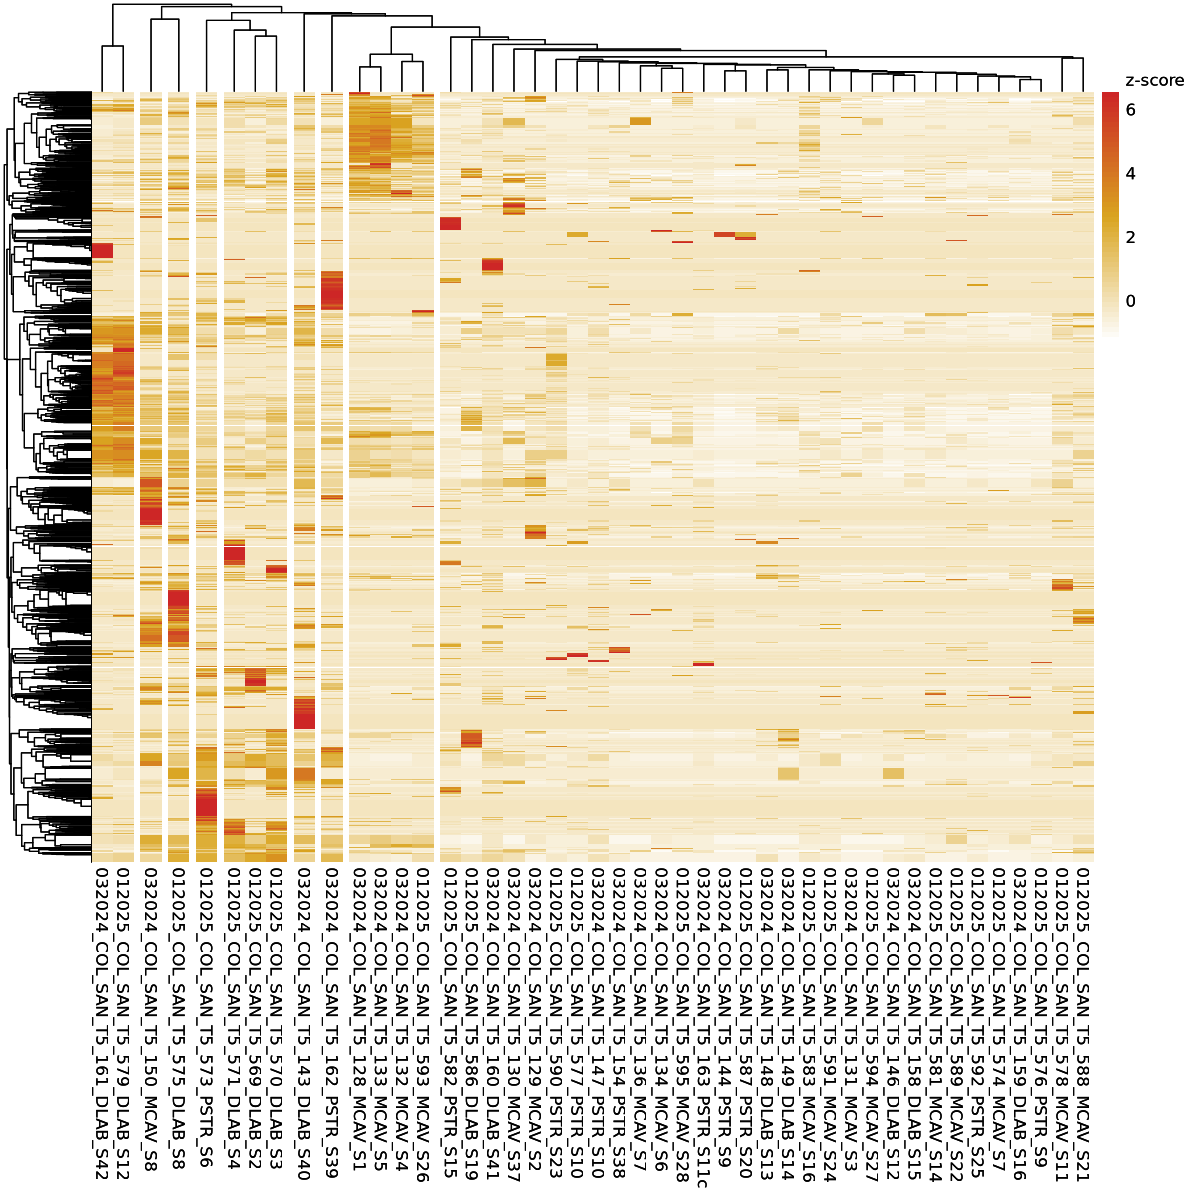

In [160]:
#look at col clusters now
genes_plot_dlab_pstr_mcav_obj_col <- pheatmap(mat_z_no_ofavs, cutree_cols = 9,
                                         show_rownames = FALSE,
                                         legend_breaks = c(0, 2, 4, 6, max(mat_z_no_ofavs)),
                                         legend_labels = c("0", "2", "4", "6", "z-score\n"),
                                         legend=TRUE,
                                         scale = "none",
                                         color = colorRampPalette(c("white", "goldenrod", "firebrick3"))(50))
genes_plot_dlab_pstr_mcav_obj_col

In [161]:
ggsave(filename = "dlab_pstr_mcav_gene_heatmap_col_clusters.png", plot = genes_plot_dlab_pstr_mcav_obj_col, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

In [162]:
ggsave(filename = "dlab_pstr_mcav_gene_heatmap_col_clusters_big.png", plot = genes_plot_dlab_pstr_mcav_obj_col, 
      width = 15,
      height = 15,
      units = "in",
      dpi = 300)

### Just OFAVs now

In [149]:
genes_filtered_reordered_ofavs <- read.csv("genes_filtered_reordered_ofavs.csv")
dim(genes_filtered_reordered_ofavs)

[1] 3405   12

In [150]:
#index gene_family_row
row.names(genes_filtered_reordered_ofavs) <- genes_filtered_reordered_ofavs$Gene_Family
genes_filtered_reordered_ofavs$Gene_Family <- NULL
#remove the Gene_family column
#genes_filtered_reordered_no_ofavs <- genes_filtered_reordered_no_ofavs[, -1]
names(genes_filtered_reordered_ofavs) <- sub("^X", "", names(genes_filtered_reordered_ofavs))
head(genes_filtered_reordered_ofavs)

,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,012025_COL_SAN_T5_596_OFAV_S29
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,0,0,0,9.45823,0,0.00000,0,0,0,0
1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,0,0,0,0.00000,0,5.41724,0,0,0,0
1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0,0,0,0.00000,0,0.00000,0,0,0,0
1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],0,0,0,0,0.00000,0,5.85221,0,0,0,0
1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],0,0,0,0,0.00000,0,0.00000,0,0,0,0
1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0,0,0,0,0.00000,0,0.00000,0,0,0,0


In [151]:
#remove rows with zero sum
genes_filtered_reordered_ofavs_num <- genes_filtered_reordered_ofavs[rowSums(genes_filtered_reordered_ofavs) != 0, ]
dim(genes_filtered_reordered_ofavs_num)
head(genes_filtered_reordered_ofavs_num)

[1] 1647   11

,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,012025_COL_SAN_T5_596_OFAV_S29
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0.00000,0,0,0.0000,9.45823,0,0.00000,0.00000,0,0,0
1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0.00000,0,0,0.0000,0.00000,0,5.41724,0.00000,0,0,0
1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],0.00000,0,0,0.0000,0.00000,0,5.85221,0.00000,0,0,0
1.1.1.271-RXN: (expasy) GDP-L-fucose synthase [1.1.1.271],0.00000,0,0,14.6519,0.00000,0,0.00000,1.90312,0,0,0
1.1.1.272-RXN: (expasy) D-2-hydroxyacid dehydrogenase (NADP(+)) [1.1.1.272],0.00000,0,0,13.3522,0.00000,0,0.00000,0.00000,0,0,0
"1.1.1.274-RXN: (expasy) 2,5-didehydrogluconate reductase (2-dehydro-D-gluconate-forming) [1.1.1.274]",6.21746,0,0,0.0000,0.00000,0,0.00000,0.00000,0,0,0


In [152]:
#calculate z-score 
mat_z_ofavs <- t(scale(t(genes_filtered_reordered_ofavs_num)))

In [154]:
options(repr.plot.width=10, repr.plot.height=10)

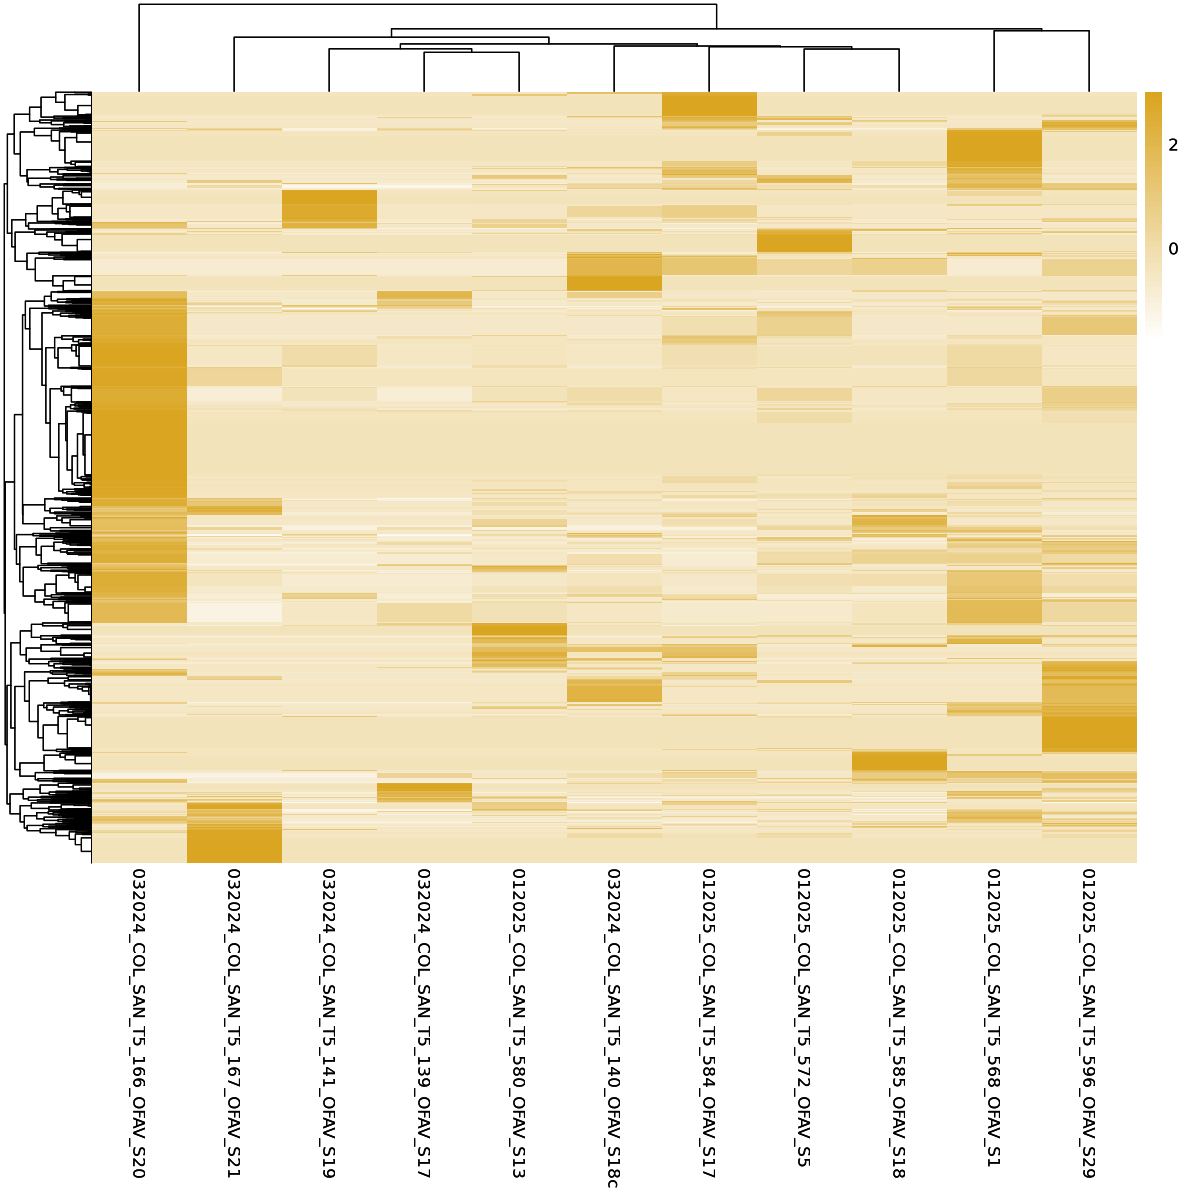

In [156]:
genes_plot_ofavs <- pheatmap(mat_z_ofavs, 
         cluster_rows = TRUE, 
         cluster_cols = TRUE,
         show_rownames = FALSE,
         legend_breaks = c(0, 2, 4, 6, max(mat_z_no_ofavs)),
         legend_labels = c("0", "2", "4", "6", "z-score\n"),
         legend=TRUE,
         scale = "none", # Already Z-scored if used mat_z, or use scale="row" on unscaled mat_filtered
         color = colorRampPalette(c("white", "goldenrod"))(50))
genes_plot_ofavs

In [157]:
ggsave(filename = "ofav_gene_heatmap.png", plot = genes_plot_ofavs, 
      width = 10,
      height = 10,
      units = "in",
      dpi = 300)

#### Try with normalization by relative abundance instead of cpm

In [25]:
genes_relab = read.csv("all_genefamilies_filtered_rxn_relab_named.csv")

In [26]:
#change headers
names(genes_relab)[1] <- "Gene_Family"
names(genes_relab) <- sub("^X", "", names(genes_relab))
names(genes_relab) <- sub("_comb_kraken_filtered_Abundance.RELAB","", names(genes_relab))
#remove specific rows
genes_relab_filtered <- genes_relab[!grepl("UNMAPPED|UNGROUPED", genes_relab$Gene_Family), ]
#genes_relab <- genes_relab[!grepl("UNGROUPED", genes_relab$Gene_Family), ]
head(genes_relab_filtered)

,Gene_Family,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,0.00000e+00,3.72786e-05,2.57496e-05,0.00000e+00,1.89406e-05,0,2.21238e-05,0,⋯,5.50468e-05,0,0,0,2.36842e-05,5.60423e-06,0.00000e+00,0,0,9.45823e-06
7,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51]|unclassified,0,0.00000e+00,3.72786e-05,2.57496e-05,0.00000e+00,1.89406e-05,0,2.21238e-05,0,⋯,5.50468e-05,0,0,0,2.36842e-05,5.60423e-06,0.00000e+00,0,0,9.45823e-06
8,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,4.93798e-05,0.00000e+00,0.00000e+00,5.41724e-06,1.61020e-05,0,2.99394e-05,0,⋯,2.82153e-06,0,0,0,0.00000e+00,1.11788e-05,2.26396e-05,0,0,0.00000e+00
9,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127]|unclassified,0,4.93798e-05,0.00000e+00,0.00000e+00,5.41724e-06,1.61020e-05,0,2.99394e-05,0,⋯,2.82153e-06,0,0,0,0.00000e+00,1.11788e-05,2.26396e-05,0,0,0.00000e+00
10,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0.00000e+00,0.00000e+00,0.00000e+00,0.00000e+00,3.96876e-06,0,0.00000e+00,0,⋯,8.27379e-06,0,0,0,0.00000e+00,0.00000e+00,0.00000e+00,0,0,0.00000e+00
11,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136]|unclassified,0,0.00000e+00,0.00000e+00,0.00000e+00,0.00000e+00,3.96876e-06,0,0.00000e+00,0,⋯,8.27379e-06,0,0,0,0.00000e+00,0.00000e+00,0.00000e+00,0,0,0.00000e+00


In [27]:
#remove the "unclassified" versions 
genes_relab_filtered <- genes_relab_filtered[!grepl("unclassified", genes_relab_filtered$Gene_Family), ]
#remove rows with "g__Cutibacterium.s__Cutibacterium_acnes" and "g__Bradyrhizobium.s__Bradyrhizobium_sp_MOS004"
genes_relab_filtered <- genes_relab_filtered[!grepl("g__Bradyrhizobium.s__Bradyrhizobium_sp_MOS004|g__Cutibacterium.s__Cutibacterium_acnes|g__Moraxella.s__Moraxella_osloensis", genes_relab_filtered$Gene_Family), ]
head(genes_relab_filtered)
dim (genes_relab_filtered)

,Gene_Family,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,0.00000e+00,3.72786e-05,2.57496e-05,0.00000e+00,1.89406e-05,0,2.21238e-05,0,⋯,5.50468e-05,0,0,0,2.36842e-05,5.60423e-06,0.00000e+00,0,0,9.45823e-06
8,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,4.93798e-05,0.00000e+00,0.00000e+00,5.41724e-06,1.61020e-05,0,2.99394e-05,0,⋯,2.82153e-06,0,0,0,0.00000e+00,1.11788e-05,2.26396e-05,0,0,0.00000e+00
10,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0.00000e+00,0.00000e+00,0.00000e+00,0.00000e+00,3.96876e-06,0,0.00000e+00,0,⋯,8.27379e-06,0,0,0,0.00000e+00,0.00000e+00,0.00000e+00,0,0,0.00000e+00
12,1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],0,0.00000e+00,0.00000e+00,0.00000e+00,5.85221e-06,0.00000e+00,0,0.00000e+00,0,⋯,0.00000e+00,0,0,0,0.00000e+00,0.00000e+00,0.00000e+00,0,0,0.00000e+00
14,1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],0,0.00000e+00,0.00000e+00,0.00000e+00,0.00000e+00,0.00000e+00,0,0.00000e+00,0,⋯,0.00000e+00,0,0,0,0.00000e+00,3.24777e-05,0.00000e+00,0,0,0.00000e+00
16,1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0,0.00000e+00,0.00000e+00,0.00000e+00,0.00000e+00,0.00000e+00,0,0.00000e+00,0,⋯,0.00000e+00,0,0,0,0.00000e+00,6.43232e-05,0.00000e+00,0,0,0.00000e+00


[1] 3405   57

In [30]:
#reorder columns from list file (just concatenated the IDs together in the order I wanted
#also included Gene_Family first, to keep that the first column
column_list <- readLines("COL_column_order.txt")
genes_relab_filtered_reordered <- genes_relab_filtered[, column_list]
head(genes_relab_filtered_reordered)
dim(genes_relab_filtered_reordered)

,Gene_Family,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,⋯,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,012025_COL_SAN_T5_587_PSTR_S20,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,0,0,0,9.45823e-06,0,0.00000e+00,0,0,⋯,0,0,0.00000e+00,1.89406e-05,0,0.00000e+00,0,1.20018e-05,0.00000e+00,0
8,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,0,0,0,0.00000e+00,0,5.41724e-06,0,0,⋯,0,0,2.26396e-05,1.61020e-05,0,7.75194e-06,0,0.00000e+00,5.02233e-05,0
10,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0,0,0,0.00000e+00,0,0.00000e+00,0,0,⋯,0,0,0.00000e+00,3.96876e-06,0,0.00000e+00,0,0.00000e+00,0.00000e+00,0
12,1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],0,0,0,0,0.00000e+00,0,5.85221e-06,0,0,⋯,0,0,0.00000e+00,0.00000e+00,0,0.00000e+00,0,0.00000e+00,0.00000e+00,0
14,1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],0,0,0,0,0.00000e+00,0,0.00000e+00,0,0,⋯,0,0,0.00000e+00,0.00000e+00,0,0.00000e+00,0,0.00000e+00,1.38331e-05,0
16,1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0,0,0,0,0.00000e+00,0,0.00000e+00,0,0,⋯,0,0,0.00000e+00,0.00000e+00,0,0.00000e+00,0,0.00000e+00,1.16232e-05,0


[1] 3405   57

In [29]:
#remove the Gene_family column
genes_relab_filtered_reordered_counts <- genes_relab_filtered_reordered[, -1]
head(genes_relab_filtered_reordered_counts)

,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,⋯,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,012025_COL_SAN_T5_587_PSTR_S20,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,0,0,0,0,9.45823e-06,0,0.00000e+00,0,0,0,⋯,0,0,0.00000e+00,1.89406e-05,0,0.00000e+00,0,1.20018e-05,0.00000e+00,0
8,0,0,0,0,0.00000e+00,0,5.41724e-06,0,0,0,⋯,0,0,2.26396e-05,1.61020e-05,0,7.75194e-06,0,0.00000e+00,5.02233e-05,0
10,0,0,0,0,0.00000e+00,0,0.00000e+00,0,0,0,⋯,0,0,0.00000e+00,3.96876e-06,0,0.00000e+00,0,0.00000e+00,0.00000e+00,0
12,0,0,0,0,0.00000e+00,0,5.85221e-06,0,0,0,⋯,0,0,0.00000e+00,0.00000e+00,0,0.00000e+00,0,0.00000e+00,0.00000e+00,0
14,0,0,0,0,0.00000e+00,0,0.00000e+00,0,0,0,⋯,0,0,0.00000e+00,0.00000e+00,0,0.00000e+00,0,0.00000e+00,1.38331e-05,0
16,0,0,0,0,0.00000e+00,0,0.00000e+00,0,0,0,⋯,0,0,0.00000e+00,0.00000e+00,0,0.00000e+00,0,0.00000e+00,1.16232e-05,0


In [32]:
#remove rows with zero sum
genes_relab_filtered_reordered_counts_num <- genes_relab_filtered_reordered_counts[rowSums(genes_relab_filtered_reordered_counts) != 0, ]
dim(genes_relab_filtered_reordered_counts_num)

[1] 3405   56

In [59]:
#turn into matrix
genes_relab_filtered_reordered_counts=as.matrix(genes_relab_filtered_reordered_counts)
head(genes_relab_filtered_reordered_counts)

,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,⋯,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,012025_COL_SAN_T5_587_PSTR_S20,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25
6,0,0,0,0,9.45823e-06,0,0.00000e+00,0,0,0,⋯,0,0,0.00000e+00,1.89406e-05,0,0.00000e+00,0,1.20018e-05,0.00000e+00,0
8,0,0,0,0,0.00000e+00,0,5.41724e-06,0,0,0,⋯,0,0,2.26396e-05,1.61020e-05,0,7.75194e-06,0,0.00000e+00,5.02233e-05,0
10,0,0,0,0,0.00000e+00,0,0.00000e+00,0,0,0,⋯,0,0,0.00000e+00,3.96876e-06,0,0.00000e+00,0,0.00000e+00,0.00000e+00,0
12,0,0,0,0,0.00000e+00,0,5.85221e-06,0,0,0,⋯,0,0,0.00000e+00,0.00000e+00,0,0.00000e+00,0,0.00000e+00,0.00000e+00,0
14,0,0,0,0,0.00000e+00,0,0.00000e+00,0,0,0,⋯,0,0,0.00000e+00,0.00000e+00,0,0.00000e+00,0,0.00000e+00,1.38331e-05,0
16,0,0,0,0,0.00000e+00,0,0.00000e+00,0,0,0,⋯,0,0,0.00000e+00,0.00000e+00,0,0.00000e+00,0,0.00000e+00,1.16232e-05,0


In [61]:
#calculate z-score 
mat_relab_z <- t(scale(t(genes_relab_filtered_reordered_counts)))

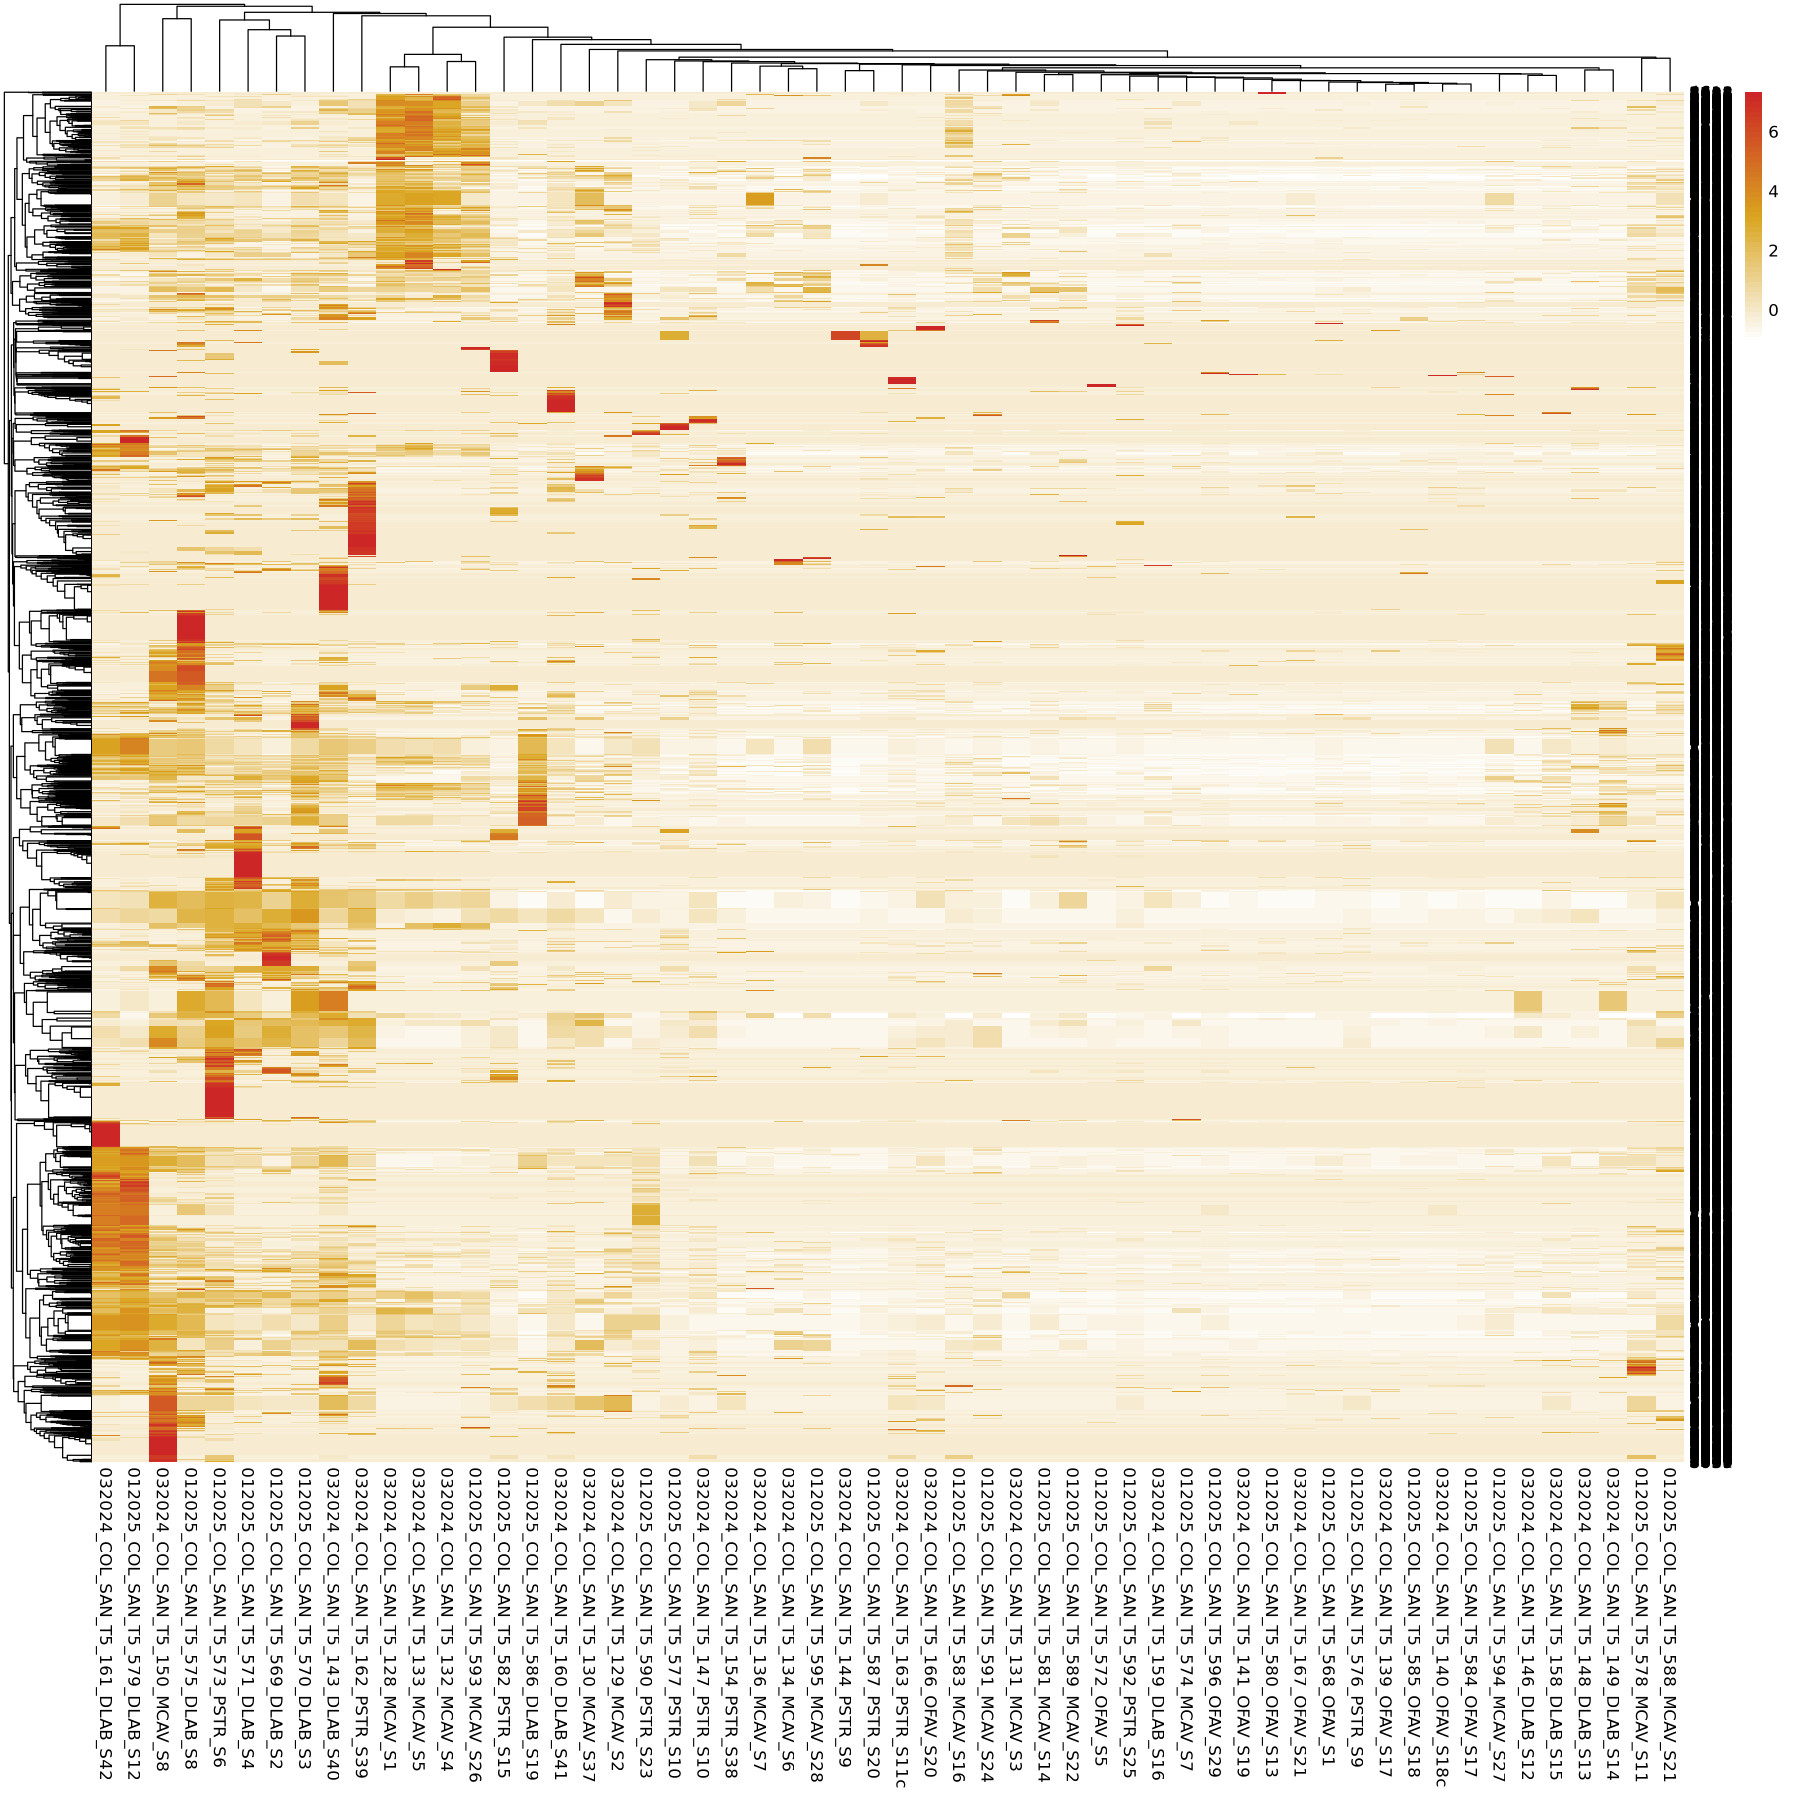

In [62]:
pheatmap(mat_relab_z, 
         cluster_rows = TRUE, 
         cluster_cols = TRUE,
         scale = "none", # Already Z-scored if used mat_z, or use scale="row" on unscaled mat_filtered
         color = colorRampPalette(c("white", "goldenrod", "firebrick3"))(50))

In [24]:
genes_filtered_reordered_transposed <- as.matrix(t(genes_filtered_reordered))
head(genes_filtered_reordered_transposed)

,6,8,10,12,14,16,18,20,22,25,⋯,9757,9759,9761,9764,9766,9769,9771,9774,9777,9779
Gene_Family,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],1.1.1.268-RXN: (expasy) 2-(R)-hydroxypropyl-CoM dehydrogenase [1.1.1.268],1.1.1.269-RXN: (expasy) 2-(S)-hydroxypropyl-CoM dehydrogenase [1.1.1.269],1.1.1.271-RXN: (expasy) GDP-L-fucose synthase [1.1.1.271],1.1.1.272-RXN: (expasy) D-2-hydroxyacid dehydrogenase (NADP(+)) [1.1.1.272],⋯,UROGENIIISYN-RXN: (expasy) Uroporphyrinogen-III synthase [4.2.1.75],URPHOS-RXN: (expasy) AMBIGUOUS [2.4.2.2; 2.4.2.3],VALINE--TRNA-LIGASE-RXN: (expasy) Valine--tRNA ligase [6.1.1.9],VALINE-PYRUVATE-AMINOTRANSFER-RXN: (expasy) Valine--pyruvate transaminase [2.6.1.66],XANPRIBOSYLTRAN-RXN: (expasy) Xanthine phosphoribosyltransferase [2.4.2.22],XANTHINE-OXIDASE-RXN: (expasy) Xanthine oxidase [1.17.3.2],XANTHOSINEPHOSPHORY-RXN: (expasy) Purine-nucleoside phosphorylase [2.4.2.1],XMPXAN-RXN: (expasy) 5'-nucleotidase [3.1.3.5],XYLISOM-RXN: (expasy) Xylose isomerase [5.3.1.5],XYLULOKIN-RXN: (expasy) Xylulokinase [2.7.1.17]
032024_COL_SAN_T5_139_OFAV_S17,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,⋯,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,12.18400,0.00000
032024_COL_SAN_T5_140_OFAV_S18c,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,⋯,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
032024_COL_SAN_T5_141_OFAV_S19,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,⋯,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,14.32890,0.00000,0.00000
032024_COL_SAN_T5_166_OFAV_S20,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,14.65190,13.35220,⋯,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,9.28183,0.00000,10.44770
032024_COL_SAN_T5_167_OFAV_S21,9.45823,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,⋯,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000


#### variance stabilizing transformation for heatmap

In [69]:
raw_genes <- read.csv("all_genefamilies_filtered_named.csv")
head(raw_genes)

,X..Gene.Family,X012025_COL_SAN_T5_568_OFAV_S1_comb_kraken_filtered_Abundance.RPKs,X012025_COL_SAN_T5_569_DLAB_S2_comb_kraken_filtered_Abundance.RPKs,X012025_COL_SAN_T5_570_DLAB_S3_comb_kraken_filtered_Abundance.RPKs,X012025_COL_SAN_T5_571_DLAB_S4_comb_kraken_filtered_Abundance.RPKs,X012025_COL_SAN_T5_572_OFAV_S5_comb_kraken_filtered_Abundance.RPKs,X012025_COL_SAN_T5_573_PSTR_S6_comb_kraken_filtered_Abundance.RPKs,X012025_COL_SAN_T5_574_MCAV_S7_comb_kraken_filtered_Abundance.RPKs,X012025_COL_SAN_T5_575_DLAB_S8_comb_kraken_filtered_Abundance.RPKs,X012025_COL_SAN_T5_576_PSTR_S9_comb_kraken_filtered_Abundance.RPKs,⋯,X032024_COL_SAN_T5_150_MCAV_S8_comb_kraken_filtered_Abundance.RPKs,X032024_COL_SAN_T5_154_PSTR_S38_comb_kraken_filtered_Abundance.RPKs,X032024_COL_SAN_T5_158_DLAB_S15_comb_kraken_filtered_Abundance.RPKs,X032024_COL_SAN_T5_159_DLAB_S16_comb_kraken_filtered_Abundance.RPKs,X032024_COL_SAN_T5_160_DLAB_S41_comb_kraken_filtered_Abundance.RPKs,X032024_COL_SAN_T5_161_DLAB_S42_comb_kraken_filtered_Abundance.RPKs,X032024_COL_SAN_T5_162_PSTR_S39_comb_kraken_filtered_Abundance.RPKs,X032024_COL_SAN_T5_163_PSTR_S11c_comb_kraken_filtered_Abundance.RPKs,X032024_COL_SAN_T5_166_OFAV_S20_comb_kraken_filtered_Abundance.RPKs,X032024_COL_SAN_T5_167_OFAV_S21_comb_kraken_filtered_Abundance.RPKs
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,UNGROUPED,809579.2,125851.7,527769.27798,422439.48340,991534.8,608088.82439,156728.4,914351.30704,414559.7,⋯,309659.90102,250041.5,183562.6,200063.4,427986.12030,1.651329e+06,444899.87,805593.9,448900.3,3.677994e+05
2,UNGROUPED|g__Bradyrhizobium.s__Bradyrhizobium_sp_MOS004,0.0,0.0,0.00000,0.00000,0.0,0.00000,0.0,0.00000,0.0,⋯,0.00000,0.0,0.0,0.0,0.00000,0.000000e+00,87959.29,0.0,0.0,0.000000e+00
3,UNGROUPED|g__Cutibacterium.s__Cutibacterium_acnes,0.0,0.0,0.00000,51880.17563,0.0,0.00000,0.0,0.00000,0.0,⋯,0.00000,0.0,0.0,0.0,0.00000,0.000000e+00,0.00,0.0,0.0,0.000000e+00
4,UNGROUPED|g__Moraxella.s__Moraxella_osloensis,0.0,0.0,0.00000,0.00000,0.0,0.00000,0.0,0.00000,0.0,⋯,0.00000,0.0,0.0,0.0,0.00000,0.000000e+00,0.00,0.0,0.0,0.000000e+00
5,UNGROUPED|unclassified,809579.2,125851.7,527769.27798,370559.30776,991534.8,608088.82439,156728.4,914351.30704,414559.7,⋯,309659.90102,250041.5,183562.6,200063.4,427986.12030,1.651329e+06,356940.58,805593.9,448900.3,3.677994e+05
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0.0,0.0,24.23341,12.88197,0.0,13.91574,0.0,25.70368,0.0,⋯,22.08522,0.0,0.0,0.0,11.09398,1.217658e+01,0.00,0.0,0.0,3.498477e+00


In [72]:
#change headers
names(raw_genes)[1] <- "Gene_Family"
names(raw_genes) <- sub("^X", "", names(raw_genes))
names(raw_genes) <- sub("_comb_kraken_filtered_Abundance.RPKs","", names(raw_genes))
#remove specific rows
raw_genes_filtered <- raw_genes[!grepl("UNMAPPED|UNGROUPED", raw_genes$Gene_Family), ]

In [73]:
#remove the "unclassified" versions 
raw_genes_filtered <- raw_genes_filtered[!grepl("unclassified", raw_genes_filtered$Gene_Family), ]
#remove rows with specific bacteria
raw_genes_filtered <- raw_genes_filtered[!grepl("g__Bradyrhizobium.s__Bradyrhizobium_sp_MOS004|g__Cutibacterium.s__Cutibacterium_acnes|g__Moraxella.s__Moraxella_osloensis", raw_genes_filtered$Gene_Family), ]
head(raw_genes_filtered)
dim (raw_genes_filtered)

,Gene_Family,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_569_DLAB_S2,012025_COL_SAN_T5_570_DLAB_S3,012025_COL_SAN_T5_571_DLAB_S4,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_574_MCAV_S7,012025_COL_SAN_T5_575_DLAB_S8,012025_COL_SAN_T5_576_PSTR_S9,⋯,032024_COL_SAN_T5_150_MCAV_S8,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_158_DLAB_S15,032024_COL_SAN_T5_159_DLAB_S16,032024_COL_SAN_T5_160_DLAB_S41,032024_COL_SAN_T5_161_DLAB_S42,032024_COL_SAN_T5_162_PSTR_S39,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,0.000000,24.23341,12.88197,0.000000,13.915738,0,25.70368,0,⋯,22.085217,0,0,0,11.09398,12.17658,0.00000,0,0,3.498477
8,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,7.121851,0.00000,0.00000,5.405405,11.830162,0,34.78403,0,⋯,1.132019,0,0,0,0.00000,24.28864,11.57776,0,0,0.000000
10,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0.000000,0.00000,0.00000,0.000000,2.915857,0,0.00000,0,⋯,3.319509,0,0,0,0.00000,0.00000,0.00000,0,0,0.000000
12,1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],0,0.000000,0.00000,0.00000,5.839429,0.000000,0,0.00000,0,⋯,0.000000,0,0,0,0.00000,0.00000,0.00000,0,0,0.000000
14,1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],0,0.000000,0.00000,0.00000,0.000000,0.000000,0,0.00000,0,⋯,0.000000,0,0,0,0.00000,70.56590,0.00000,0,0,0.000000
16,1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0,0.000000,0.00000,0.00000,0.000000,0.000000,0,0.00000,0,⋯,0.000000,0,0,0,0.00000,139.75798,0.00000,0,0,0.000000


[1] 3405   57

In [101]:
#reorder columns from list file (just concatenated the IDs together in the order I wanted
#also included Gene_Family first, to keep that the first column
column_list <- readLines("COL_column_order.txt")
raw_genes_filtered_reordered <- raw_genes_filtered[, column_list]
head(raw_genes_filtered_reordered)

,Gene_Family,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,⋯,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,012025_COL_SAN_T5_587_PSTR_S20,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,1-ACYLGLYCEROL-3-P-ACYLTRANSFER-RXN: (expasy) 1-acylglycerol-3-phosphate O-acyltransferase [2.3.1.51],0,0,0,0,3.498477,0,0.000000,0,0,⋯,0,0,0.00000,13.915738,0,0.000000,0,7.125578,0.00000,0
8,1.1.1.127-RXN: (expasy) 2-dehydro-3-deoxy-D-gluconate 5-dehydrogenase [1.1.1.127],0,0,0,0,0.000000,0,5.405405,0,0,⋯,0,0,11.57776,11.830162,0,4.285117,0,0.000000,63.05497,0
10,1.1.1.136-RXN: (expasy) UDP-N-acetylglucosamine 6-dehydrogenase [1.1.1.136],0,0,0,0,0.000000,0,0.000000,0,0,⋯,0,0,0.00000,2.915857,0,0.000000,0,0.000000,0.00000,0
12,1.1.1.178-RXN: (expasy) 3-hydroxy-2-methylbutyryl-CoA dehydrogenase [1.1.1.178],0,0,0,0,0.000000,0,5.839429,0,0,⋯,0,0,0.00000,0.000000,0,0.000000,0,0.000000,0.00000,0
14,1.1.1.261-RXN: (expasy) sn-glycerol-1-phosphate dehydrogenase [1.1.1.261],0,0,0,0,0.000000,0,0.000000,0,0,⋯,0,0,0.00000,0.000000,0,0.000000,0,0.000000,17.36733,0
16,1.1.1.264-RXN: (expasy) L-idonate 5-dehydrogenase (NAD(P)(+)) [1.1.1.264],0,0,0,0,0.000000,0,0.000000,0,0,⋯,0,0,0.00000,0.000000,0,0.000000,0,0.000000,14.59288,0


In [102]:
#remove the Gene_family column
raw_genes_filtered_reordered_counts <- raw_genes_filtered_reordered[, -1]
head(raw_genes_filtered_reordered_counts)

,032024_COL_SAN_T5_139_OFAV_S17,032024_COL_SAN_T5_140_OFAV_S18c,032024_COL_SAN_T5_141_OFAV_S19,032024_COL_SAN_T5_166_OFAV_S20,032024_COL_SAN_T5_167_OFAV_S21,012025_COL_SAN_T5_568_OFAV_S1,012025_COL_SAN_T5_572_OFAV_S5,012025_COL_SAN_T5_580_OFAV_S13,012025_COL_SAN_T5_584_OFAV_S17,012025_COL_SAN_T5_585_OFAV_S18,⋯,032024_COL_SAN_T5_163_PSTR_S11c,032024_COL_SAN_T5_154_PSTR_S38,032024_COL_SAN_T5_162_PSTR_S39,012025_COL_SAN_T5_573_PSTR_S6,012025_COL_SAN_T5_576_PSTR_S9,012025_COL_SAN_T5_577_PSTR_S10,012025_COL_SAN_T5_582_PSTR_S15,012025_COL_SAN_T5_587_PSTR_S20,012025_COL_SAN_T5_590_PSTR_S23,012025_COL_SAN_T5_592_PSTR_S25
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
6,0,0,0,0,3.498477,0,0.000000,0,0,0,⋯,0,0,0.00000,13.915738,0,0.000000,0,7.125578,0.00000,0
8,0,0,0,0,0.000000,0,5.405405,0,0,0,⋯,0,0,11.57776,11.830162,0,4.285117,0,0.000000,63.05497,0
10,0,0,0,0,0.000000,0,0.000000,0,0,0,⋯,0,0,0.00000,2.915857,0,0.000000,0,0.000000,0.00000,0
12,0,0,0,0,0.000000,0,5.839429,0,0,0,⋯,0,0,0.00000,0.000000,0,0.000000,0,0.000000,0.00000,0
14,0,0,0,0,0.000000,0,0.000000,0,0,0,⋯,0,0,0.00000,0.000000,0,0.000000,0,0.000000,17.36733,0
16,0,0,0,0,0.000000,0,0.000000,0,0,0,⋯,0,0,0.00000,0.000000,0,0.000000,0,0.000000,14.59288,0


In [103]:
#calculate z-score 
mat_raw_z <- t(scale(t(raw_genes_filtered_reordered_counts)))

In [112]:
options(repr.plot.width=15, repr.plot.height=15)

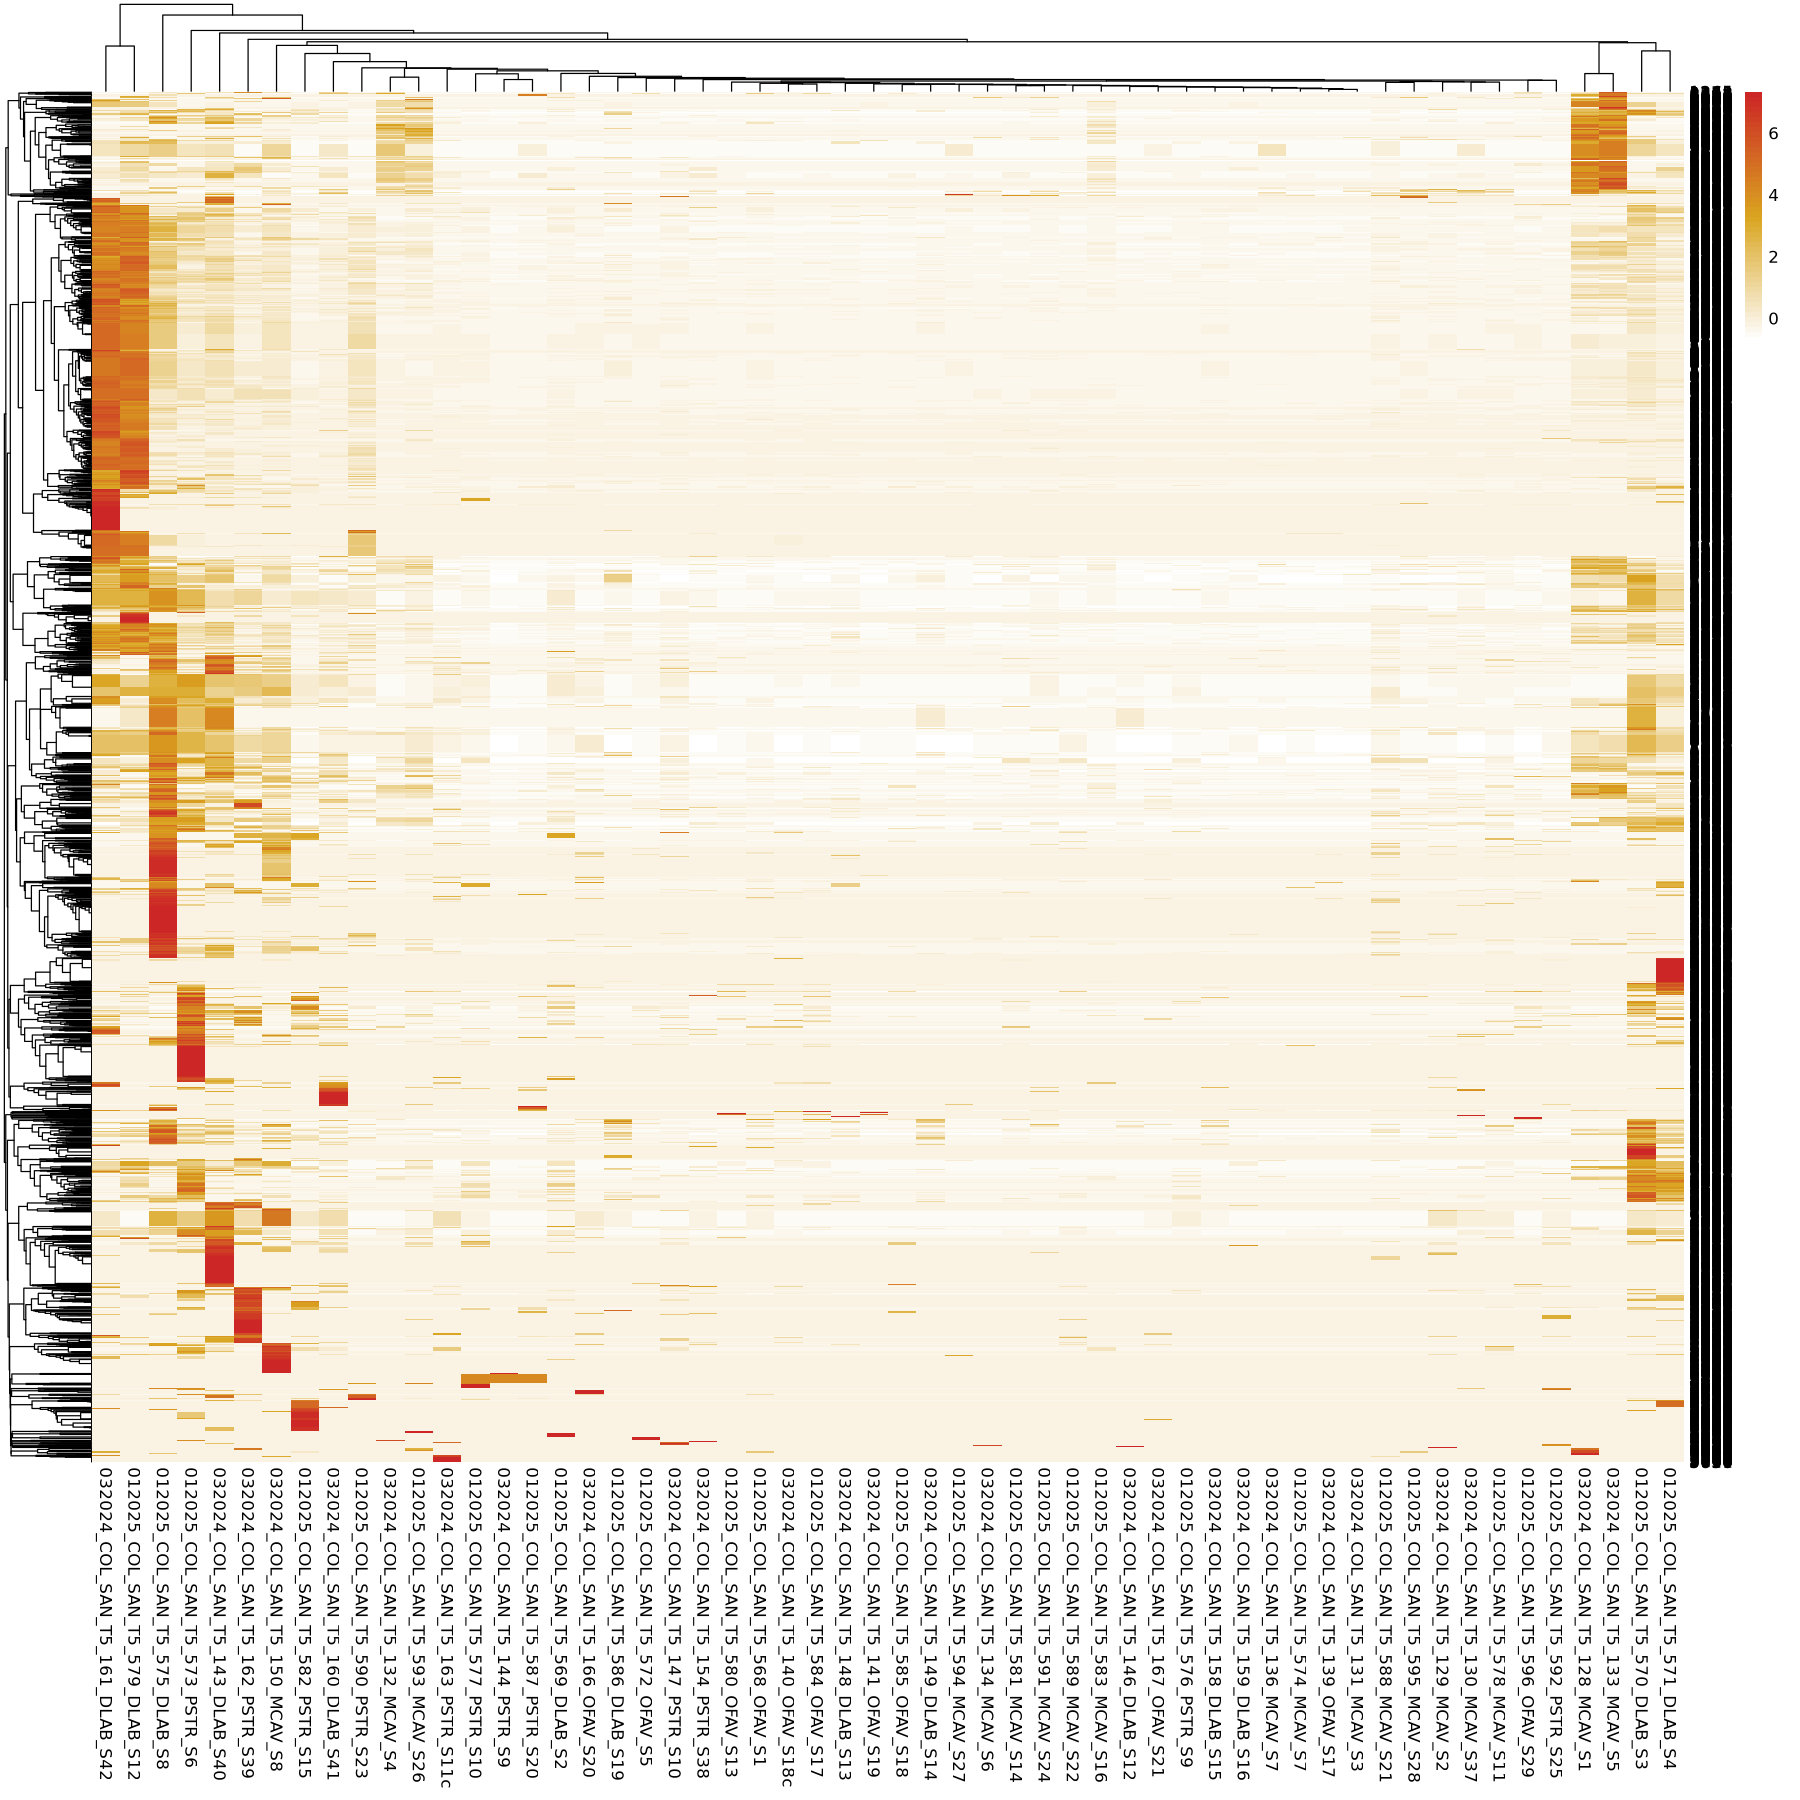

In [113]:
pheatmap(mat_raw_z, 
         cluster_rows = TRUE, 
         cluster_cols = TRUE,
         scale = "none", # Already Z-scored if used mat_z, or use scale="row" on unscaled mat_filtered
         color = colorRampPalette(c("white", "goldenrod", "firebrick3"))(50))

In [100]:
#turn decimals into integers
#raw_genes_filtered_reordered_counts[sapply(raw_genes_filtered_reordered_counts, is.numeric)] <- round(raw_genes_filtered_reordered_counts[sapply(raw_genes_filtered_reordered_counts, is.numeric)], digits = 0) 
#head(raw_genes_filtered_reordered_counts)

In [104]:
#counts_matrix <- as.matrix(genes_filtered_reordered_counts, header=TRUE)
#head(counts_matrix)

In [105]:
# read in metadata
#coldata=read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/COL/kraken_bracken/COL_metadata_012025.csv', header=TRUE)
#head(coldata)

In [106]:
#nrow(coldata_filtered)

In [107]:
#ncol(counts_matrix)

In [108]:
#dds <- DESeqDataSetFromMatrix(countData = counts_matrix,
                              colData = coldata_filtered,
                              design = ~ Tag_num)

ERROR: Error in parse(text = input): <text>:2:57: unexpected ','
1: #dds <- DESeqDataSetFromMatrix(countData = counts_matrix,
2:                               colData = coldata_filtered,
                                                           ^
